In [1]:
# Make repo root importable for this session (zero packaging)
import sys, pathlib
repo_root = pathlib.Path.cwd().parent if (pathlib.Path.cwd().name == "notebooks") else pathlib.Path.cwd()
sys.path.insert(0, str(repo_root))
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import math
import time
from datetime import datetime
import os
import shutil # for copying checkpoint to "last"
from pathlib import Path
import gc

import torch
import torch.nn as nn
import torchvision.transforms as transform

from torch.utils.tensorboard import SummaryWriter
import matplotlib.pylab as plt
%matplotlib inline
from IPython.display import Audio

from rnencodec.utils.utils import param_breakdown
from rnencodec.utils.io import save_run_config

from rnencodec.audioDataLoader.audio_dataset import LatentDatasetConfig, EnCodecLatentDataset_constant, EnCodecLatentDataset_dynamic
from rnencodec.audioDataLoader.audio_dataset import  EnCodecLatentDataset_dynamic_v2
from rnencodec.audioDataLoader.audio_dataset import  EnCodecLatentDataset_dynamic_v3, latents_to_audio_simple
from torch.utils.data import DataLoader

import rnencodec.model.gru_audio_model
from rnencodec.model.gru_audio_model import GRUModelConfig

from transformers import EncodecModel

import torch.nn.functional as F

<div style="width: 100%; height: 5px; background-color: DarkBlue;"></div>
<b>Data sets</b>

The syn7wav24_tokens_HFdataset_5 has the following parameters:   
&nbsp;&nbsp;&nbsp;&nbsp;        ['Full File Name', 'class_name', 'param1', 'param2', 'param3', 'param0', 'audio']  
and the following unique 'class_name' values:  
&nbsp;&nbsp;&nbsp;&nbsp;        Class list: ['ChirpPattern', 'DSApplause', 'DSBugs', 'DSPeepers', 'DSPistons', 'DSWind', 'TokWotalDuet']  
which you can use to filter the full dataset if you only want to train on a subset of sound classes, for example:  
&nbsp;&nbsp;&nbsp;&nbsp;        config.filters = {'class_name': {'DSPistons', 'DSApplause'}}  
<div style="width: 100%; height: 5px; background-color: DarkBlue;"></div>

### Data Params  
<a id="dataparams"></a>

These parameters are saved to file, and serve several purposes:
* The allow other programs to properly evaluate and visualize the trained (and also saved) models,
* Provide a record of the parameters that allow reproducing results. 

In [3]:
resume_checkpoint= None 
#resume_checkpoint  = str(Path('output/20260123_114246_engineC_SOFTtrial_TFCYCLE_TAU.35_topnsoft_newprep'))

dataset="enginesC" # "ddsp_violin"

if dataset=="syntex": # syntex #about 8 hours of audio for each class!
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/esteban/scratchdata/syntex24/data7wav/syn7wav24_tokens_HFdataset_5' )  # where the data files live
    savename="multiclass_test_HARDcascade" #"DSPistons_noTF"  #just a tag on the output folder 
    #props={"param1": (0,1)}
    props={"c1": (0, 1), "c2": (0, 1),"c3": (0, 1),"c4": (0, 1),"c5": (0, 1),"c6": (0, 1),"c7": (0, 1),"param1": (0,1)}
    filters= {}# {'class_name': {'TokWotalDuet'}} 
    train_split='train_sm'
    val_split='val'
    EnCodecLatentDataset=EnCodecLatentDataset_constant  #latents in .arrow file, column headers are param names, column values are param values - one value per audio file
    

if dataset=="syntex_new": # uses the new data format and v3 data loader 
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/data/syn7_v4/hf_dataset' )  # where the data files live
    savename="datapreptest_dynamic_25" #"DSPistons_noTF"  #just a tag on the output folder 
    #props={"param1": (0,1)}
    props={"param1": None, "class_ChirpPattern": None, "class_DSApplause": None,"class_DSBugs": None,"class_DSPeepers": None,"class_DSPistons": None,"class_DSWind": None,"class_TokWotalDuet": None}
    filters= {}# {'class_name': {'TokWotalDuet'}} 
    train_split='train_sm'
    val_split='validation'
    #EnCodecLatentDataset=EnCodecLatentDataset_constant  #latents in .arrow file, column headers are param names, column values are param values - one value per audio file
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic

elif dataset=="nsynth" : # nsynth
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/data/MuMeRNN/data/nsynth.64.76.ecdc24HF' )  # where the data files live
    savename="nsynth_soft_cascade"  #just a tag on the output folder 
    props={"class": (.0,1),"norm_pitch": (-.05,1.05), "norm_amp": (0,1),} #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'
    EnCodecLatentDataset=EnCodecLatentDataset_constant   #latents in .arrow file, column headers are param names, column values are param values - one value per audio file

elif dataset=="water":  #15 minutes of sound
    sourcedatadir = os.path.join(repo_root, 'artifacts/data/waterfill_quickstart_hf_dataset' )  # where the data files live
    savename="water_soft.35"  #just a tag on the output folder 
    props={"pos": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic   #latents in "sidecar" npy and json files and have as many frames as the audio file


elif dataset=="ddsp_violin":
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/DDSP_ViolinSet2/ddsp_violinset_hf' )  # where the data files live
    savename="ddsp_violin_seql_75_corrected"  #just a tag on the output folder 
    props={"pitch": None, "amp": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic_v2   #latents in "sidecar" npy and json files and have as many frames as the audio file

elif dataset=="babble_gender":
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/estaban_babble_gender/dataset_hf' )  # where the data files live
    savename="babble_gender_mf"  #just a tag on the output folder 
    props={"sex": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic_v2   #latents in "sidecar" npy and json files and have as many frames as the audio file

elif dataset=="nsynth7": # 1.5 minutes per instrument, 11 minutes of sound
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/NSynth/nsynth_7_glide_HF' )  # where the data files live
    savename="nsynth7_trial2"  #just a tag on the output folder 
    props={"pitch": None, "velocity": None, "003clarinet": None, "006frenchhorn": None,"094bass": None,"162flute": None,"272voice-ee": None,"295voice-oo": None,"887organ": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic_v2   #latents in "sidecar" npy and json files and have as many frames as the audio file

elif dataset=="enginesC":
    #sourcedatadir = os.path.join(repo_root, '/slowdisk/data/ProceduralEngineSounds/ECDC/C_full_set_ecdc_HF')
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/ProceduralEngineSounds/CSV/proceduralengine_prepped/hf_dataset')
    savename="engineC_SOFTtrial_TFCYCLE_TAU.35_topnsoft_postmerge"  #just a tag on the output folder 
    props={"RPM": None, "Torque": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train' 
    val_split='test'
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic   #latents in "sidecar" npy and json files and have as many frames as the audio file


print(f'props are {props}')
rawqweights=torch.tensor([1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3], dtype=torch.float)

params = dict(
    # Read/write directory of data & parameter files
    #*************************************
    sample_rate=24000,
    runTimeStamp='{:%Y-%m-%d_%H-%M-%S}'.format(datetime.now()),
    
    datadir = sourcedatadir,
    filters=filters,
    
    savemodel = True,
    savemodel_interval = 25, #10, # in units of epochs
    savemodeldir = os.path.join(os.getcwd(), 'output'), # default saving directory for models and the parameterization

    # Training parameters ----------------------------------------------
    num_epochs = 75, # 225, # #20, # of batches_per_epoch of batch_size sequeunce (if resuming, this is how many *more* epochs to do.
    batches_per_epoch = 100, #100, 
    batch_size = 100, #100, 
    
    noise=.05,
    seqLen = 100, #75, #14379, # 125, # 125,

    lr = 0.005,
    # parameter names for the Data Loader to search for in the filenames, and the range that maps to [0,1] for training and inference
    # The order specified in this structure will be the order used for inference
    props=props,
    
    # Model parameters -----------------
    input_size = 128,
    hiddenSize = 128, # 128, #100,
    nLayers = 3,
    inp_proportion = 5,
    cond_proportion = 2,
    codebook_size = 1024, # encodec codebook size
    dropout = 0.1,
    n_q = 8,                                # Number of codebooks to use
    quantizer_weights = rawqweights * (len(rawqweights) / rawqweights.sum()), #normed to sum to the length of the array
    clamp_val = 15,


    # training-time knobs you already have (not used yet)
    gumbel_tau_start = 1.0,
    gumbel_tau_end = 0.5,
    straight_through = True,

    # cascade selection
    cascade = "soft",  # "hard" | "soft"

    # HARD cascade knobs
    hard_sample_mode = "sample",
    top_n_hard = 3,   # used for both training and for the little inference thing I do at the end of each batch
    temperature_hard = 1.0,
    
    # SOFT cascade knobs (RNG-free unless you later add gumbel-soft)
    tau_soft = 0.35, #[peaky, .6, smoother]
    top_n_soft = 8,  # optional sparse softmax (still deterministic)

    # ----------------------------
    simulate_parallel = False,  #Simultate parallel will turn TF on and send 0's in to simulate no cascading information

    # Training parameters
    files_per_sequence=2, #important - how many different data files to draw from to create each sequence. For short seq_lens, and dynamic params, this should probably be 1
    TF_schedule = [25,25], # cycle: [TF batches, noTF batches] (make sure simulate_parallel is False if you want TF

)

# for managing the switching between TF and no TF
TF_cycle=params['TF_schedule'][0]+params['TF_schedule'][1]
use_tf = lambda epoch: (epoch % TF_cycle) < params['TF_schedule'][0]  # ['TF_schedule'][0]  on, ['TF_schedule'][1] off
#use_tf = lambda epoch: True #true means Always use no TF (first part of "cycle")

props are {'RPM': None, 'Torque': None}


In [4]:
params

{'sample_rate': 24000,
 'runTimeStamp': '2026-01-24_16-13-34',
 'datadir': '/slowdisk/data/ProceduralEngineSounds/CSV/proceduralengine_prepped/hf_dataset',
 'filters': {},
 'savemodel': True,
 'savemodel_interval': 25,
 'savemodeldir': '/home/lonce/working/RNeNcodec/dev_notebooks/output',
 'num_epochs': 75,
 'batches_per_epoch': 100,
 'batch_size': 100,
 'noise': 0.05,
 'seqLen': 100,
 'lr': 0.005,
 'props': {'RPM': None, 'Torque': None},
 'input_size': 128,
 'hiddenSize': 128,
 'nLayers': 3,
 'inp_proportion': 5,
 'cond_proportion': 2,
 'codebook_size': 1024,
 'dropout': 0.1,
 'n_q': 8,
 'quantizer_weights': tensor([1.5385, 1.3846, 1.2308, 1.0769, 0.9231, 0.7692, 0.6154, 0.4615]),
 'clamp_val': 15,
 'gumbel_tau_start': 1.0,
 'gumbel_tau_end': 0.5,
 'straight_through': True,
 'cascade': 'soft',
 'hard_sample_mode': 'sample',
 'top_n_hard': 3,
 'temperature_hard': 1.0,
 'tau_soft': 0.35,
 'top_n_soft': 8,
 'simulate_parallel': False,
 'files_per_sequence': 2,
 'TF_schedule': [25, 25]}

### Run Params 

In [5]:
sr = params['sample_rate']

log_interval = 1 # units of epochs
visualize_interval = log_interval # units of epochs

#Generation parameters
#*************************************
max_length = params['seqLen']*3  #length of the sequence used to inspect progress in audio plots during training

# Cuda
#*************************************
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
#device='cpu'
device

device(type='cuda', index=0)

In [6]:
# Some utility functions
#*************************************
def time_taken(elapsed):
    """To format time taken in hh:mm:ss. Use with time.monotic()"""
    m, s = divmod(elapsed, 60)
    h, m = divmod(m, 60)
    return "%d:%02d:%02d" % (h, m, s)

def mydate() :
    return (datetime.now().strftime("%Y-%m-%d %H:%M:%S"))



In [7]:

#--- model settings ----#
model_config = GRUModelConfig (
    input_size = params['input_size'],
    cond_size = len(params['props']),
    hidden_size = params['hiddenSize'],
    num_layers = params['nLayers'],
    codebook_size = params['codebook_size'],  #mu-law quantization levels
    dropout = params['dropout'],
    n_q=params['n_q'],

    inp_proportion = params['inp_proportion'],
    cond_proportion = params['cond_proportion'],

    # training-time knobs you already have (not used yet)
    gumbel_tau_start = params['gumbel_tau_start'],
    gumbel_tau_end = params['gumbel_tau_end'],
    straight_through = params['straight_through'],

    # cascade selection
    cascade = params['cascade'],  # "hard" | "soft"

    # HARD cascade knobs
    hard_sample_mode = params['hard_sample_mode'],
    top_n_hard = params['top_n_hard'],   # used for both training and for the little inference thing I do at the end of each batch
    temperature_hard = params['temperature_hard'],

    tau_soft = params['tau_soft'],
    top_n_soft = params['top_n_soft'],  # optional sparse softmax (still deterministic)

)

    

# ---- Training Settings ----
data_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
    add_noise= False if params['noise'] == 0 else True,   # Whether to add white noise
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters,
    files_per_sequence=params['files_per_sequence'],

    # IMPORTANT: co-located sidecars → leave cond_root = None (default)
    cond_root=None,
    cond_suffix=".cond.npy",
    strict=False,                         # skip files with missing/mismatched sidecars instead of raising

)

# ---- Generation Settings ----
testdata_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
    add_noise= False,                        # no noise for testing and priming
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters,
    files_per_sequence=params['files_per_sequence'],

    # IMPORTANT: co-located sidecars → leave cond_root = None (default)
    cond_root=None,
    cond_suffix=".cond.npy",
    strict=False,                         # skip files with missing/mismatched sidecars instead of raising

)

# === Dataset and Loader ===
# Load your EnCodec model (update path as needed)
# this model we put on the GPU (or current device) and pass it to the inference engine (the datasets will have their own copy on the CPU
enc_model = EncodecModel.from_pretrained("facebook/encodec_24khz") # leave on the cpu till we are ready to train+inferece for now
enc_model.eval()

print("✅ Configuration and model loaded")


adataset = EnCodecLatentDataset(data_config, "facebook/encodec_24khz", split=train_split)

train_loader = DataLoader(adataset,
                             batch_size=params['batch_size'],
                             shuffle=True,
                             num_workers=4,
                             drop_last=True)

testdataset = EnCodecLatentDataset(testdata_config, "facebook/encodec_24khz", split=val_split)
test_loader = DataLoader(testdataset,
                            batch_size=1,
                            shuffle=True,
                            num_workers=4,
                            drop_last=True)
   
# The data "size" is the number of possible sequences the data loader can provide.
# Since the sequences are chosen randomly from the file, the number of possible sequence is the total number of audio samples in the set (minus the ones that start less than sequence length from the end of the files)
print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

✅ Configuration and model loaded
[EnCodecLatentDataset] No filters provided; using all 700 rows.
Loaded 570014 sequences from 700 files in 'train' split
[EnCodecLatentDataset] No filters provided; using all 67 rows.
Loaded 55321 sequences from 67 files in 'test' split
size of dataset is 570014
no. of batches per epoch is 100
batchsize id  is 100


size of dataset is 570014
no. of batches per epoch is 100
batchsize id  is 100
PVECT - shape is torch.Size([100, 2])
pvect[0]: tensor([0.2757, 0.0926])
pvect[25]: tensor([0.2724, 0.0933])
pvect[last]: tensor([0.4278, 0.2511])
inp.shape is torch.Size([100, 128])


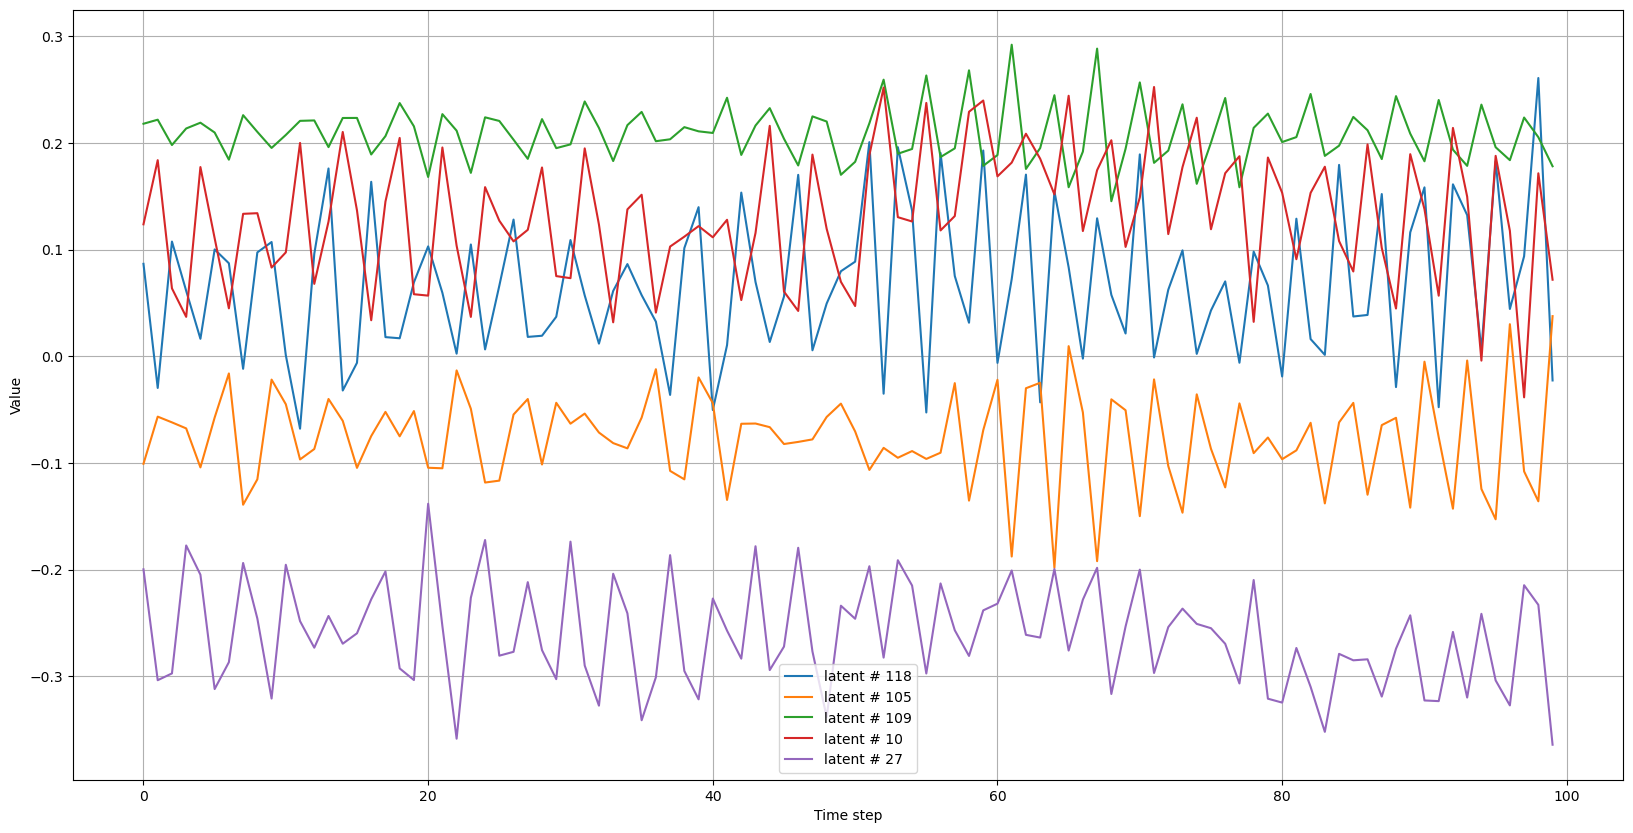

SHAPE: torch.Size([1, 128, 100])


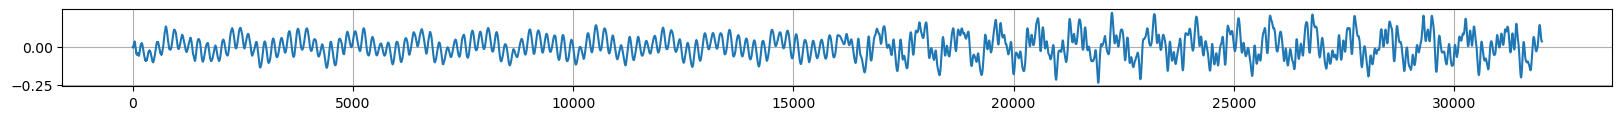

conditioning.shap = torch.Size([100, 2])


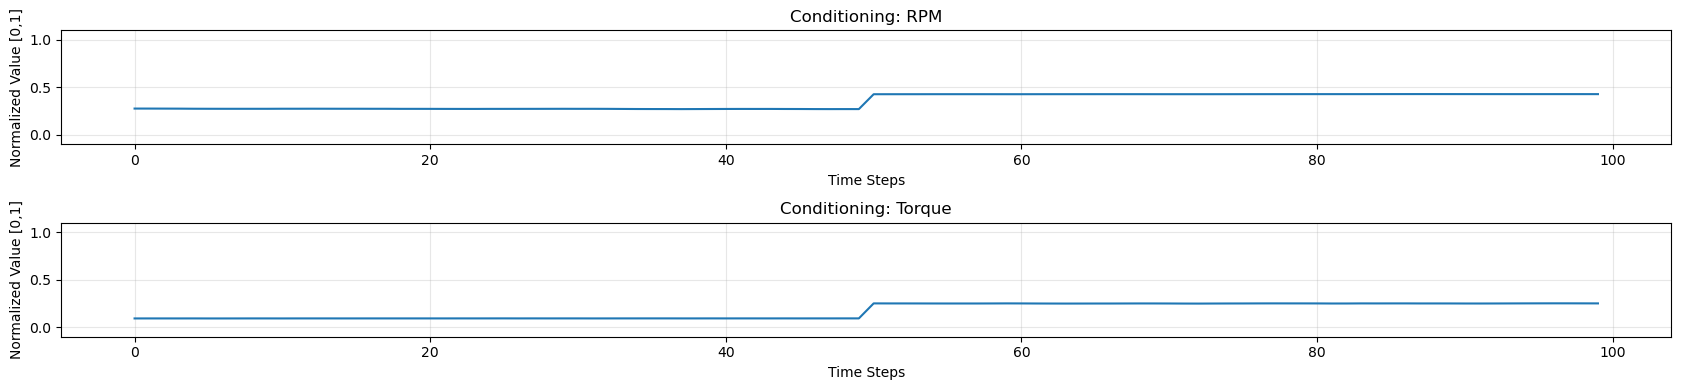

In [8]:
# just show some stuff 
def pmap(x) :
    return 55+x*(88-55)

print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

samp, target = adataset.rand_sample()  #samp.shape=(T, inputsize+cond_size)
pvect=samp[:, -model_config.cond_size:]
print(f'PVECT - shape is {pvect.shape}')
pvect0=samp[0, -model_config.cond_size:]
print(f"pvect[0]: {pvect0}")
pvect25=samp[25, -model_config.cond_size:]
print(f"pvect[25]: {pvect25}")
pvectl=samp[params['seqLen']-1, -model_config.cond_size:]
print(f"pvect[last]: {pvectl}")

inp=samp[:,:-model_config.cond_size]
print(f'inp.shape is {inp.shape}')

# Now grab n=10 random latent components and look at them over time
_, p = inp.shape
# Generate n=10 random indices from 0 to p-1
indices = torch.randperm(p)[:5]
sub_inp = inp[:, indices]
sub_inp.shape


#first print latent sequence
plt.figure(figsize=(20,10)) 
# plt.plot(np.arange(len(sub_inp)), sub_inp) #just print some example from the batch
# plt.grid()
# plt.show()

ts = np.arange(len(sub_inp))  # time steps
for i in range(sub_inp.shape[1]):   # loop over trajectories
    plt.plot(ts, sub_inp[:, i], label=f"latent # {indices[i]}")
plt.legend()
plt.xlabel("Time step")
plt.ylabel("Value")
plt.grid()
plt.show()



tokens=samp[:, :params['input_size']].T.unsqueeze(0)
print(f"SHAPE: {tokens[:,:params['input_size']].shape}")
audiosamps, sr=latents_to_audio_simple(enc_model, tokens*params['clamp_val'])
audiosamps=audiosamps[0, 0]

plt.figure(figsize=(20,1)) 
plt.plot(audiosamps) #just print one example from the batch
plt.grid()
plt.show()


#conditioning = samp[:,-model_config.cond_size:]
cvect = pvect#=samp[:, -model_config.cond_size:] # samp[:, -model_config.cond_size:].squeeze(0)  #imp_seq[0, :, -len(params['props']):]
n_params = cvect.shape[1]
print(f'conditioning.shap = {cvect.shape}')
# # Additional Analysis: Conditioning parameters over time
if n_params > 0:
    plt.figure(figsize=(17, 4))
    
    param_names = list(data_config.parameter_specs.keys())
    
    for i in range(n_params):
        plt.subplot(2, (n_params + 1) // 2, i + 1)
        plt.plot(cvect[:,i].numpy())
        param_name = param_names[i] if i < len(param_names) else f'param_{i}'
        plt.title(f'Conditioning: {param_name}')
        plt.xlabel('Time Steps')
        plt.ylabel('Normalized Value [0,1]')
        plt.grid(True, alpha=0.3)
        plt.ylim(-0.1, 1.1)
    
    plt.tight_layout()
    plt.show()

    # #print out numbers
    # cvect_mapped = torch.stack([pmap(cvect[:, 0]), cvect[:, 1]], dim=1)
    # print(f"conditioning params: {cvect_mapped}")

#Another check just to see that the ecdc and params are coming from the same file and using the same starting sample number (no using the random sample as above)
# entry = adataset.sequence_map[0]         # (dataset_idx, start_frame, token_file_path)
# ds_idx, start, token_path = entry
# cpath = adataset._cond_path_for(token_path)
# print("codes:", token_path.name, "cond:", cpath.name, "start:", start)


#This is the "rand_samp" plotted above"
Audio(audiosamps, rate=params['sample_rate'])

In [9]:

def prepare_target_codebook_latents(rnn_model, target_codes, scales_bq=None):
    """
    target_codes: (B, n_q) LongTensor for a single timestep
    returns: List[n_q] of (B, D=128) latents, one per codebook (level 0..n_q-1)
    """
    dev = rnn_model._E_eff.device
    codes_bq = target_codes.to(dev, dtype=torch.long, non_blocking=True)
    if scales_bq is not None:
        scales_bq = scales_bq.to(dev, non_blocking=True)

    out = []
    for q in range(rnn_model.n_q):
        E_q = rnn_model._E_eff[q]                    # (K, D)
        e_q = F.embedding(codes_bq[:, q], E_q)       # (B, D)
        if scales_bq is not None:
            e_q = e_q * scales_bq[:, q].unsqueeze(-1)
        out.append(e_q)
    return out

In [10]:
# Define the training cycle (100% teacher forcing for now)
#*************************************

def train(model,encodec_model, epoch):

 model.train() #put in training mode
 ave_loss_over_steps = 0
 debug_seqs=0

 for batch_num, (inp, target) in enumerate(train_loader):
    debug_seqs += len(inp)
    inp, target = inp.to(device), target.to(device)
    
    hidden = model.init_hidden(params['batch_size'])
    optimizer.zero_grad()
    loss = 0
    
    # Initialize per-quantizer loss tracking
    quantizer_losses = [0.0] * params['n_q']
    
    # Define quantizer weights
    quantizer_weights = params['quantizer_weights'][:params['n_q']]
     
    for i in range(params['seqLen']):  # causal: one time step at a time
        if params['simulate_parallel']:
            use_teacher_forcing = True
            # just placeholders for shape when sim-parallel; zeros are fine
            tflatents = [torch.zeros(params['batch_size'], params['input_size'], device=device)
                         for _ in range(params['n_q'])]
        else:
            use_teacher_forcing = use_tf(epoch)
            if use_teacher_forcing:
                # prepare ground-truth per-level latents (List[n_q * (B,128)])
                tflatents = prepare_target_codebook_latents(model, target[:, i, :]) # uses model's decoder
            else:
                tflatents = None
    
        # --- ONE call; ONE set of sampled tokens used everywhere ---
        logits_list, hidden, sampled_indices, step_latent = model(
            inp[:, i, :],
            hidden,
            target_codebook_latents=tflatents,
            use_teacher_forcing=use_teacher_forcing,
            return_step_latent=False, # this is for "self conditioning"

        )
    
        # --- CE loss exactly as before (per-quantizer) ---
        for j in range(params['n_q']):
            quantizer_loss = criterion(logits_list[j], target[:, i, j])
            quantizer_losses[j] += quantizer_loss.item()
            loss = loss + quantizer_weights[j] * quantizer_loss
    
        # # --- Self-conditioning for next step: feed SAME latent forward ---
        # if i + 1 < params['seqLen']:
        #     # step_latent is:
        #     #  - the sum of teacher-forced per-level latents if TF,
        #     #  - the sum of decoded sampled tokens if AR.
        #     # Use .detach() for stable training (no across-time grads for now).
        #     inp[:, i + 1, :params['input_size']] = step_latent.detach()
    
    loss = loss / params['seqLen']
    quantizer_losses = [ql / params['seqLen'] for ql in quantizer_losses]
    
    loss.backward()
    optimizer.step()
    
    ave_loss_per_sample = loss.item()/params['seqLen']   #over each minibatch
    #ave_loss_over_steps += ave_loss_per_sample
    
    # Accumulate quantizer losses over the epoch
    if batch_num == 0:  # Initialize on first batch
        epoch_quantizer_losses = [0.0] * params['n_q']
    
    for j in range(params['n_q']):
        epoch_quantizer_losses[j] += quantizer_losses[j]
    
    if batch_num>=(params['batches_per_epoch']-1):
        break


    per_q_time_mean = [s / params['seqLen'] for s in quantizer_losses]  # each is batch-mean, time-mean
    overall_time_mean = float(torch.dot(quantizer_weights, torch.tensor(per_q_time_mean, device=quantizer_weights.device)).item())

    
 print(f"Finished epoch number {epoch} with a total of {debug_seqs} debug_seqs")
 if (epoch+1) % log_interval == 0:
    print(f" time: {datetime.now()}, epoch {epoch+1},  Loss: {ave_loss_per_sample:.4f}")
    list_of_losses.append(ave_loss_per_sample)
    writer.add_scalar("Loss/train", ave_loss_per_sample, epoch+1)
    writer.add_scalar("overall_time_mean", overall_time_mean, epoch+1)
    
    # Log individual quantizer losses (averaged over the epoch)
    num_batches = min(batch_num + 1, params['batches_per_epoch'])
    for j in range(params['n_q']):
        avg_quantizer_loss = epoch_quantizer_losses[j] / num_batches
        writer.add_scalar(f"Loss/quantizer_{j}", avg_quantizer_loss, epoch+1)
        print(f"  Quantizer {j} Loss: {avg_quantizer_loss:.4f}")

 if (epoch+1) % visualize_interval == 0:

     # these two lines address a resource management issues with temporary directories ...  I think....
     torch.cuda.empty_cache()  # if using GPU
     gc.collect()

     result = newgen(model,max_length)
     print(f'plot the audio which has shape {result.shape}')
     plt.figure(figsize=(20,1))
     plt.plot(np.arange(len(result)), result) #just print one example from the batch
     plt.show()
     model.train() #put model back to training mode


 # overwrite the last, and save a numbered checkpoint
 if (epoch + 1) % params['savemodel_interval'] == 0:
    checkpoint_data = {
        'epoch': epoch+1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }
    
    # Save numbered checkpoint
    numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
    torch.save(checkpoint_data, numbered_path)
    
    # Copy to "last" (much faster than saving twice)
    last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    shutil.copy2(numbered_path, last_path)
    
    print(f"Saved checkpoint at epoch {epoch+1}")

In [11]:
# ---- Create Output Folders ----
if resume_checkpoint != None:
    out_dir = resume_checkpoint
else:
    run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = os.path.join(params['savemodeldir'], run_timestamp + "_"+savename)
    os.makedirs(out_dir, exist_ok=True)

    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(f"{out_dir}/checkpoints", exist_ok=True)
    os.makedirs(f"{out_dir}/tensorboard", exist_ok=True)

save_run_config(f"{out_dir}/config_v2.pt", params=None, model_config=model_config, data_config=data_config)
print(f"wrote {out_dir}/config_v2.pt")

saved to /home/lonce/working/RNeNcodec/dev_notebooks/output/20260124_161336_engineC_SOFTtrial_TFCYCLE_TAU.35_topnsoft_postmerge/config_v2.pt
wrote json param file
wrote /home/lonce/working/RNeNcodec/dev_notebooks/output/20260124_161336_engineC_SOFTtrial_TFCYCLE_TAU.35_topnsoft_postmerge/config_v2.pt


In [12]:
import copy
from rnencodec.generator import RNNGenerator

inference_model_config=copy.deepcopy(model_config)
inference_model_config.cascade='hard' # 
inference_model_config.hard_sample_mode="sample"
inference_model_config.top_n_hard=12
inference_model_config.temperature_hard=1.0


def newgen(model,max_length):
    #This hack allows us to "configure" the model for generation differently - in particular how it is sampled (which may be different from how it is trained)
    inference_model = rnencodec.model.gru_audio_model.RNN(model_config, enc_model).to('cpu')
    inference_model.load_state_dict(model.state_dict())

    #override these values of state
    inference_model.cascade='hard' # 
    inference_model.hard_sample_mode="sample"
    inference_model.top_n_hard=12
    inference_model.temperature_hard=1.0



    rnninference=RNNGenerator(inference_model, inference_model_config, testdata_config, enc_model, max_length, max_length)
    
    # grab a random conditioning vector from the data set
    p_inp, _ = next(iter(test_loader)) # don't need targets
    c = p_inp[:, 0, -inference_model_config.cond_size:].squeeze(0).to(device) #grab a random input sequence
    print(f'DEVICE going in: model tensors {next(model.parameters()).device}, enc_model {enc_model.device}, c {c.device}')
    print(f'About toInitialize generator with c.shape = {c.shape}') 
    rnninference.warmup(c,10)
    gen = rnninference.getNextAudioHop(c, hop=max_length)
    
    return gen

In [13]:
inference_model_config

GRUModelConfig(input_size=128, cond_size=2, hidden_size=128, num_layers=3, n_q=8, codebook_size=1024, dropout=0.1, inp_proportion=5, cond_proportion=2, gumbel_tau_start=1.0, gumbel_tau_end=0.5, straight_through=True, cascade='hard', hard_sample_mode='sample', top_n_hard=12, temperature_hard=1.0, tau_soft=0.35, top_n_soft=8)

### Load the model 

In [14]:

rnn = rnencodec.model.gru_audio_model.RNN(model_config, enc_model).to(device)
    
optimizer = torch.optim.Adam(rnn.parameters(), lr=params['lr'])
criterion = nn.CrossEntropyLoss(reduction='mean')

start_epoch=0

if resume_checkpoint:
    checkpoint_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    assert os.path.exists(checkpoint_path), f"File {checkpoint_path} does not exist"
    checkpoint = torch.load(checkpoint_path)
    rnn.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resumed from checkpoint at epoch {start_epoch}")

writer = SummaryWriter(log_dir=f"{out_dir}/tensorboard")

Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128


In [15]:
num_trainable_params = sum(p.numel() for p in rnn.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_trainable_params}")

bd = param_breakdown(rnn, trainable_only=True) #prints out a breakdown of the parameter counts per layter
# pretty print
print(f"latent_proj: {bd['latent_proj']:,}")
print(f"cond_proj:   {bd['cond_proj']:,}")
print(f"GRU total:   {bd['gru_total']:,}")
for k, v in bd['gru_layers'].items():
    print(f"  {k}: {v:,}")
print("Decoders (per head):")
for i, n in enumerate(bd['decoders']):
    print(f"  decoder[{i}]: {n:,}")
print(f"Decoders total: {bd['decoders_total']:,}")
print(f"Model total:    {bd['model_total']:,}")


n_q, K, D = rnn._E_eff.shape
print(f"✅ E_eff is built: n_q={n_q}, K={K}, D={D}, device={rnn._E_eff.device}")
# per-level shapes (each should be (K, D))
print("Per-level shapes:", [tuple(rnn._E_eff[q].shape) for q in range(n_q)])


# 1) Make sure both models are on the same device
device = next(rnn.parameters()).device
enc_model = enc_model.to(device)

B, T = 4, 7
codes = torch.randint(0, rnn.codebook_size, (B, T, rnn.n_q), device=device, dtype=torch.long)

# 3) Manual path via cached effective tables (matches Encodec exactly)
z_manual = rnn._codes_to_latent_sum(codes)                           # (B, T, D)

# 4) Encodec path (expects (n_q, B, T))
z_decode = enc_model.quantizer.decode(codes.permute(2, 0, 1))        # (B, D, T)
z_decode = z_decode.permute(0, 2, 1).contiguous()                    # (B, T, D)

# 5) Compare
diff = (z_manual - z_decode).abs()
print("DIFFERENCE — max|Δ|=", diff.max().item(), "mean|Δ|=", diff.mean().item())

Total trainable parameters: 2414410
latent_proj: 11,739
cond_proj:   111
GRU total:   297,216
  l0/fwd: 99,072
  l1/fwd: 99,072
  l2/fwd: 99,072
Decoders (per head):
  decoder[0]: 263,168
  decoder[1]: 263,168
  decoder[2]: 263,168
  decoder[3]: 263,168
  decoder[4]: 263,168
  decoder[5]: 263,168
  decoder[6]: 263,168
  decoder[7]: 263,168
Decoders total: 2,105,344
Model total:    2,414,410
✅ E_eff is built: n_q=8, K=1024, D=128, device=cuda:0
Per-level shapes: [(1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128)]
DIFFERENCE — max|Δ|= 0.0 mean|Δ|= 0.0


2026-01-24 16:13:37 Starting training...
Finished epoch number 0 with a total of 10000 debug_seqs
 time: 2026-01-24 16:13:57.736972, epoch 1,  Loss: 0.3462
  Quantizer 0 Loss: 4.2501
  Quantizer 1 Loss: 5.0507
  Quantizer 2 Loss: 4.9509
  Quantizer 3 Loss: 4.9501
  Quantizer 4 Loss: 4.8840
  Quantizer 5 Loss: 4.8948
  Quantizer 6 Loss: 4.9290
  Quantizer 7 Loss: 4.9292
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


/home/lonce/working/RNeNcodec/rnencodec/generator/generator.py:160: UserWarning: Warning: ....... chunk size 300 is <= hop size 300. RETURNING full hop and continuing
  warnings.warn(f"Warning: ....... chunk size {T} is <= hop size {h}. RETURNING full hop and continuing")


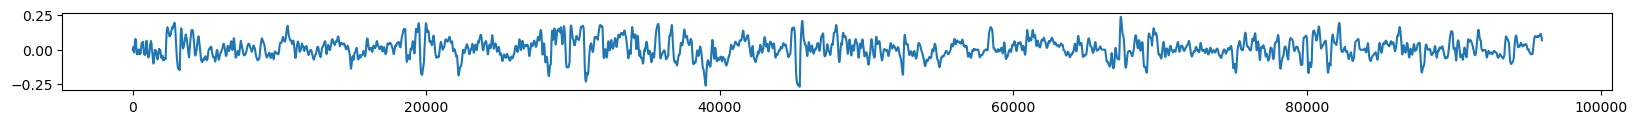

Finished epoch number 1 with a total of 10000 debug_seqs
 time: 2026-01-24 16:14:19.693244, epoch 2,  Loss: 0.3444
  Quantizer 0 Loss: 3.6228
  Quantizer 1 Loss: 4.5573
  Quantizer 2 Loss: 4.4560
  Quantizer 3 Loss: 4.4751
  Quantizer 4 Loss: 4.4128
  Quantizer 5 Loss: 4.4168
  Quantizer 6 Loss: 4.4588
  Quantizer 7 Loss: 4.4614
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


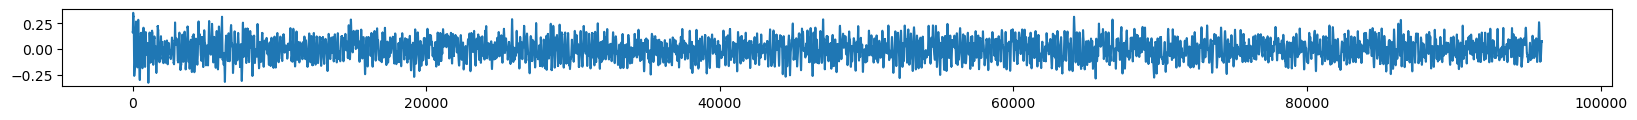

Finished epoch number 2 with a total of 10000 debug_seqs
 time: 2026-01-24 16:14:41.817300, epoch 3,  Loss: 0.3370
  Quantizer 0 Loss: 3.4735
  Quantizer 1 Loss: 4.4823
  Quantizer 2 Loss: 4.3980
  Quantizer 3 Loss: 4.4064
  Quantizer 4 Loss: 4.3557
  Quantizer 5 Loss: 4.3393
  Quantizer 6 Loss: 4.3877
  Quantizer 7 Loss: 4.3925
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


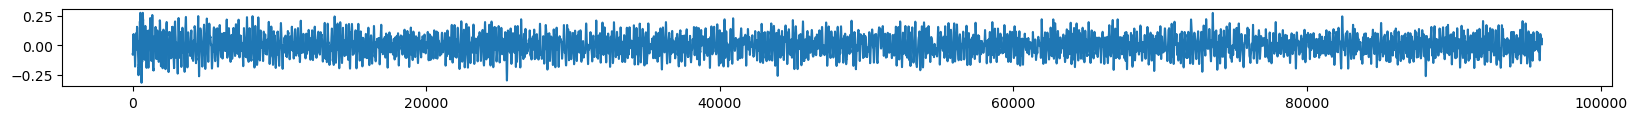

Finished epoch number 3 with a total of 10000 debug_seqs
 time: 2026-01-24 16:15:04.456716, epoch 4,  Loss: 0.3124
  Quantizer 0 Loss: 3.1373
  Quantizer 1 Loss: 4.2955
  Quantizer 2 Loss: 4.2927
  Quantizer 3 Loss: 4.3133
  Quantizer 4 Loss: 4.2700
  Quantizer 5 Loss: 4.2545
  Quantizer 6 Loss: 4.3081
  Quantizer 7 Loss: 4.3084
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


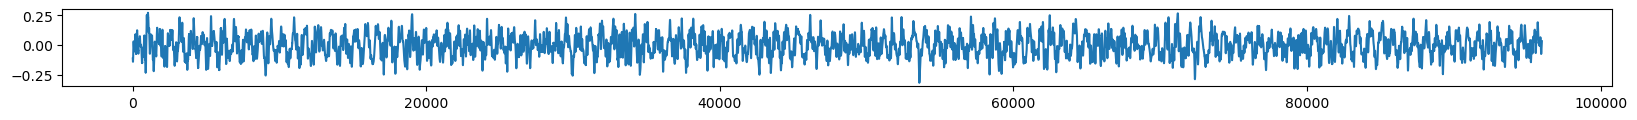

Finished epoch number 4 with a total of 10000 debug_seqs
 time: 2026-01-24 16:15:26.571488, epoch 5,  Loss: 0.3021
  Quantizer 0 Loss: 2.8565
  Quantizer 1 Loss: 4.0509
  Quantizer 2 Loss: 4.1516
  Quantizer 3 Loss: 4.2102
  Quantizer 4 Loss: 4.1832
  Quantizer 5 Loss: 4.1820
  Quantizer 6 Loss: 4.2474
  Quantizer 7 Loss: 4.2431
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


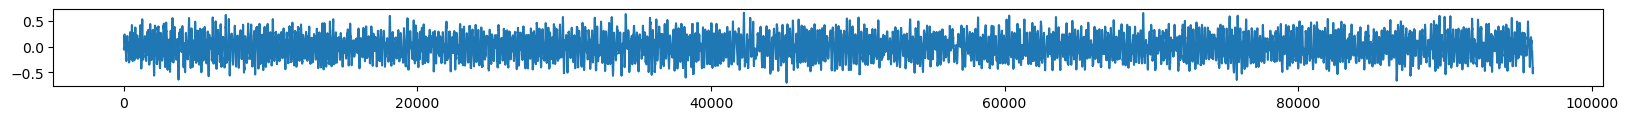

Finished epoch number 5 with a total of 10000 debug_seqs
 time: 2026-01-24 16:15:48.784047, epoch 6,  Loss: 0.3002
  Quantizer 0 Loss: 2.6091
  Quantizer 1 Loss: 3.8197
  Quantizer 2 Loss: 4.0215
  Quantizer 3 Loss: 4.1135
  Quantizer 4 Loss: 4.1034
  Quantizer 5 Loss: 4.1142
  Quantizer 6 Loss: 4.1897
  Quantizer 7 Loss: 4.1823
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


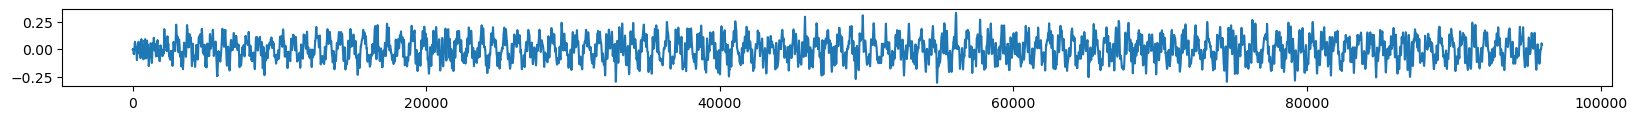

Finished epoch number 6 with a total of 10000 debug_seqs
 time: 2026-01-24 16:16:10.451320, epoch 7,  Loss: 0.2893
  Quantizer 0 Loss: 2.4251
  Quantizer 1 Loss: 3.6753
  Quantizer 2 Loss: 3.9243
  Quantizer 3 Loss: 4.0339
  Quantizer 4 Loss: 4.0391
  Quantizer 5 Loss: 4.0614
  Quantizer 6 Loss: 4.1425
  Quantizer 7 Loss: 4.1320
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


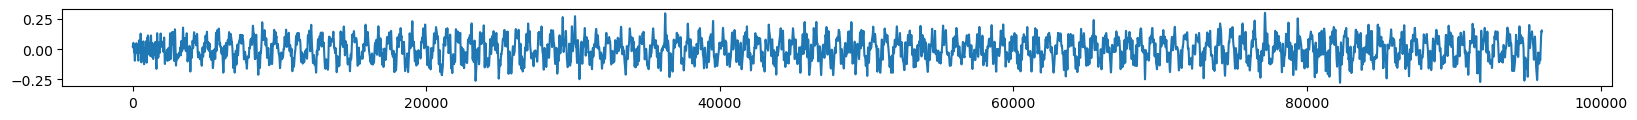

Finished epoch number 7 with a total of 10000 debug_seqs
 time: 2026-01-24 16:16:32.825611, epoch 8,  Loss: 0.2937
  Quantizer 0 Loss: 2.2816
  Quantizer 1 Loss: 3.5723
  Quantizer 2 Loss: 3.8605
  Quantizer 3 Loss: 3.9877
  Quantizer 4 Loss: 4.0075
  Quantizer 5 Loss: 4.0273
  Quantizer 6 Loss: 4.1071
  Quantizer 7 Loss: 4.1046
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


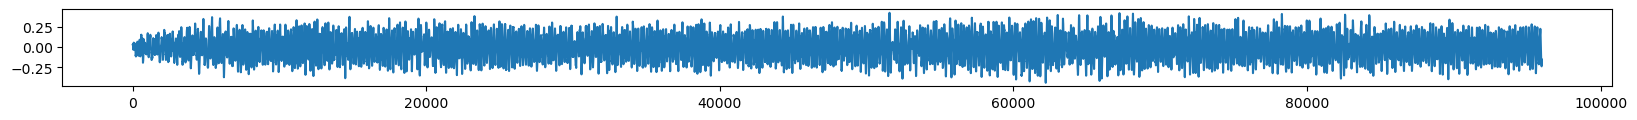

Finished epoch number 8 with a total of 10000 debug_seqs
 time: 2026-01-24 16:16:55.214543, epoch 9,  Loss: 0.2759
  Quantizer 0 Loss: 2.1709
  Quantizer 1 Loss: 3.4848
  Quantizer 2 Loss: 3.8193
  Quantizer 3 Loss: 3.9667
  Quantizer 4 Loss: 3.9880
  Quantizer 5 Loss: 4.0188
  Quantizer 6 Loss: 4.0998
  Quantizer 7 Loss: 4.1030
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


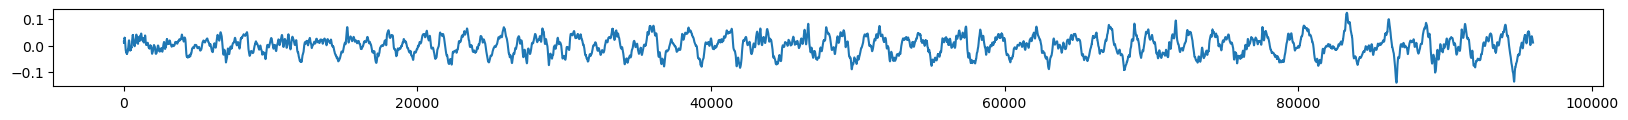

Finished epoch number 9 with a total of 10000 debug_seqs
 time: 2026-01-24 16:17:18.168686, epoch 10,  Loss: 0.2813
  Quantizer 0 Loss: 2.0380
  Quantizer 1 Loss: 3.3675
  Quantizer 2 Loss: 3.7397
  Quantizer 3 Loss: 3.8979
  Quantizer 4 Loss: 3.9293
  Quantizer 5 Loss: 3.9517
  Quantizer 6 Loss: 4.0405
  Quantizer 7 Loss: 4.0443
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


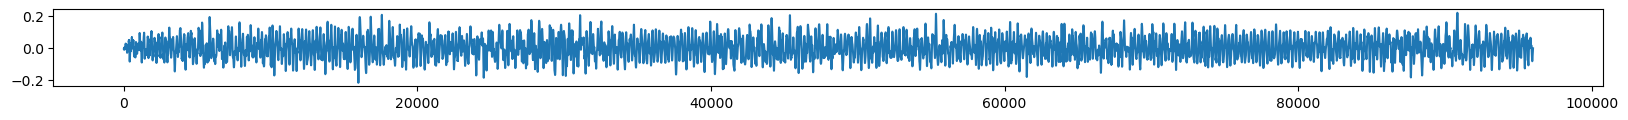

Finished epoch number 10 with a total of 10000 debug_seqs
 time: 2026-01-24 16:17:40.212892, epoch 11,  Loss: 0.2681
  Quantizer 0 Loss: 1.9537
  Quantizer 1 Loss: 3.2976
  Quantizer 2 Loss: 3.6904
  Quantizer 3 Loss: 3.8662
  Quantizer 4 Loss: 3.9101
  Quantizer 5 Loss: 3.9347
  Quantizer 6 Loss: 4.0292
  Quantizer 7 Loss: 4.0337
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


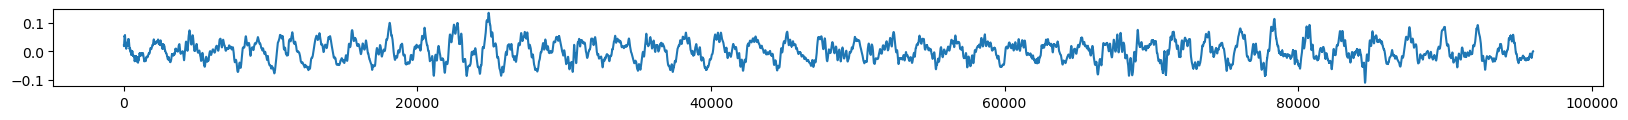

Finished epoch number 11 with a total of 10000 debug_seqs
 time: 2026-01-24 16:18:03.262674, epoch 12,  Loss: 0.2637
  Quantizer 0 Loss: 1.8574
  Quantizer 1 Loss: 3.2169
  Quantizer 2 Loss: 3.6367
  Quantizer 3 Loss: 3.8255
  Quantizer 4 Loss: 3.8729
  Quantizer 5 Loss: 3.8988
  Quantizer 6 Loss: 4.0027
  Quantizer 7 Loss: 4.0030
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


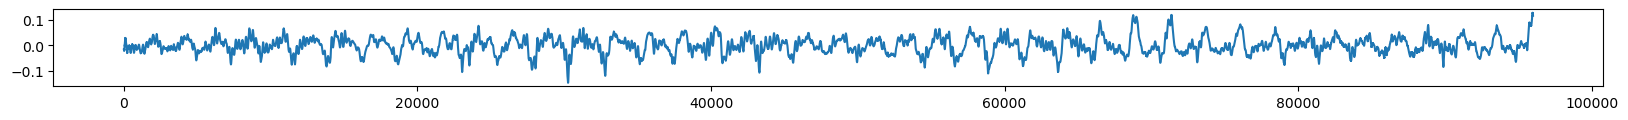

Finished epoch number 12 with a total of 10000 debug_seqs
 time: 2026-01-24 16:18:25.060180, epoch 13,  Loss: 0.2620
  Quantizer 0 Loss: 1.7918
  Quantizer 1 Loss: 3.1536
  Quantizer 2 Loss: 3.6039
  Quantizer 3 Loss: 3.8003
  Quantizer 4 Loss: 3.8543
  Quantizer 5 Loss: 3.8937
  Quantizer 6 Loss: 3.9884
  Quantizer 7 Loss: 3.9882
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


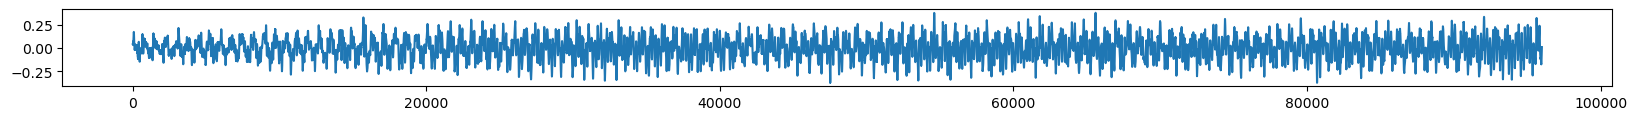

Finished epoch number 13 with a total of 10000 debug_seqs
 time: 2026-01-24 16:18:46.853639, epoch 14,  Loss: 0.2635
  Quantizer 0 Loss: 1.7346
  Quantizer 1 Loss: 3.0938
  Quantizer 2 Loss: 3.5600
  Quantizer 3 Loss: 3.7797
  Quantizer 4 Loss: 3.8449
  Quantizer 5 Loss: 3.8810
  Quantizer 6 Loss: 3.9799
  Quantizer 7 Loss: 3.9865
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


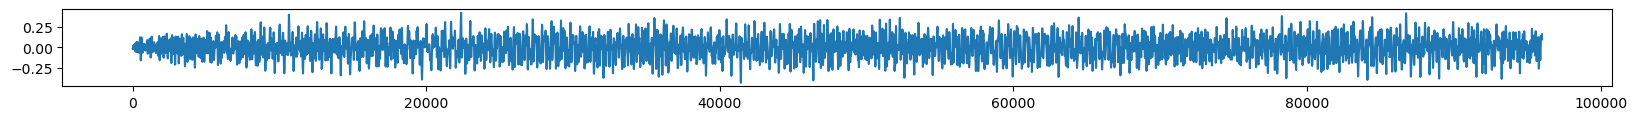

Finished epoch number 14 with a total of 10000 debug_seqs
 time: 2026-01-24 16:19:09.237686, epoch 15,  Loss: 0.2561
  Quantizer 0 Loss: 1.6739
  Quantizer 1 Loss: 3.0185
  Quantizer 2 Loss: 3.5127
  Quantizer 3 Loss: 3.7397
  Quantizer 4 Loss: 3.8090
  Quantizer 5 Loss: 3.8517
  Quantizer 6 Loss: 3.9485
  Quantizer 7 Loss: 3.9562
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


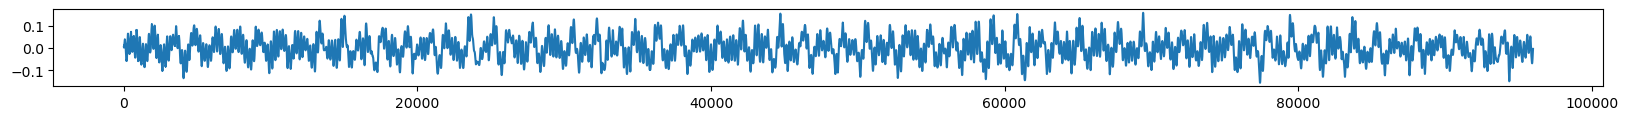

Finished epoch number 15 with a total of 10000 debug_seqs
 time: 2026-01-24 16:19:31.820646, epoch 16,  Loss: 0.2573
  Quantizer 0 Loss: 1.6291
  Quantizer 1 Loss: 2.9663
  Quantizer 2 Loss: 3.4742
  Quantizer 3 Loss: 3.7155
  Quantizer 4 Loss: 3.7905
  Quantizer 5 Loss: 3.8346
  Quantizer 6 Loss: 3.9318
  Quantizer 7 Loss: 3.9434
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


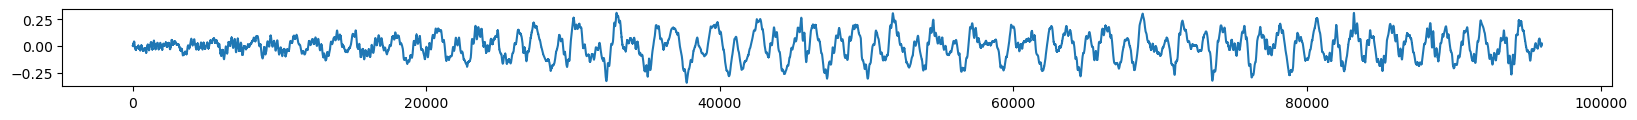

Finished epoch number 16 with a total of 10000 debug_seqs
 time: 2026-01-24 16:19:53.921550, epoch 17,  Loss: 0.2507
  Quantizer 0 Loss: 1.5881
  Quantizer 1 Loss: 2.9193
  Quantizer 2 Loss: 3.4482
  Quantizer 3 Loss: 3.7001
  Quantizer 4 Loss: 3.7808
  Quantizer 5 Loss: 3.8351
  Quantizer 6 Loss: 3.9348
  Quantizer 7 Loss: 3.9413
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


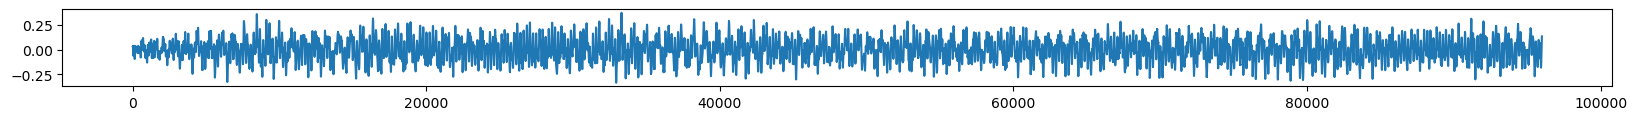

Finished epoch number 17 with a total of 10000 debug_seqs
 time: 2026-01-24 16:20:16.486584, epoch 18,  Loss: 0.2540
  Quantizer 0 Loss: 1.5675
  Quantizer 1 Loss: 2.8919
  Quantizer 2 Loss: 3.4321
  Quantizer 3 Loss: 3.6894
  Quantizer 4 Loss: 3.7797
  Quantizer 5 Loss: 3.8277
  Quantizer 6 Loss: 3.9314
  Quantizer 7 Loss: 3.9465
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


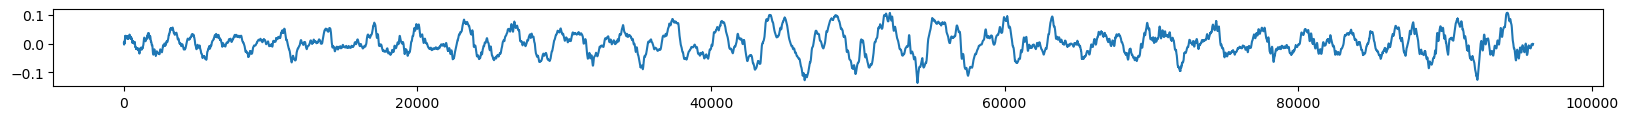

Finished epoch number 18 with a total of 10000 debug_seqs
 time: 2026-01-24 16:20:39.223565, epoch 19,  Loss: 0.2483
  Quantizer 0 Loss: 1.5159
  Quantizer 1 Loss: 2.8233
  Quantizer 2 Loss: 3.3718
  Quantizer 3 Loss: 3.6358
  Quantizer 4 Loss: 3.7316
  Quantizer 5 Loss: 3.7879
  Quantizer 6 Loss: 3.8990
  Quantizer 7 Loss: 3.9069
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


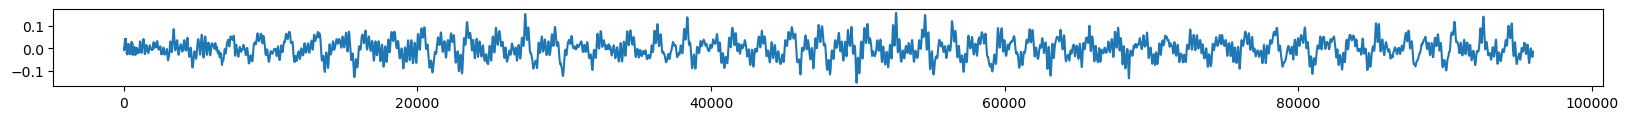

Finished epoch number 19 with a total of 10000 debug_seqs
 time: 2026-01-24 16:21:01.277294, epoch 20,  Loss: 0.2444
  Quantizer 0 Loss: 1.5047
  Quantizer 1 Loss: 2.8064
  Quantizer 2 Loss: 3.3683
  Quantizer 3 Loss: 3.6381
  Quantizer 4 Loss: 3.7407
  Quantizer 5 Loss: 3.8013
  Quantizer 6 Loss: 3.9080
  Quantizer 7 Loss: 3.9214
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


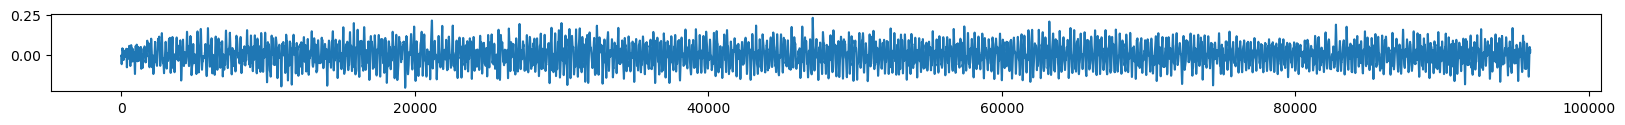

Finished epoch number 20 with a total of 10000 debug_seqs
 time: 2026-01-24 16:21:23.574706, epoch 21,  Loss: 0.2467
  Quantizer 0 Loss: 1.4719
  Quantizer 1 Loss: 2.7588
  Quantizer 2 Loss: 3.3237
  Quantizer 3 Loss: 3.6096
  Quantizer 4 Loss: 3.7125
  Quantizer 5 Loss: 3.7706
  Quantizer 6 Loss: 3.8836
  Quantizer 7 Loss: 3.8946
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


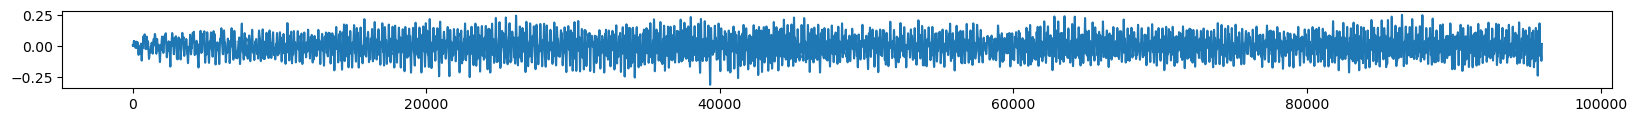

Finished epoch number 21 with a total of 10000 debug_seqs
 time: 2026-01-24 16:21:46.161646, epoch 22,  Loss: 0.2389
  Quantizer 0 Loss: 1.4615
  Quantizer 1 Loss: 2.7447
  Quantizer 2 Loss: 3.3142
  Quantizer 3 Loss: 3.5943
  Quantizer 4 Loss: 3.7008
  Quantizer 5 Loss: 3.7618
  Quantizer 6 Loss: 3.8709
  Quantizer 7 Loss: 3.8827
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


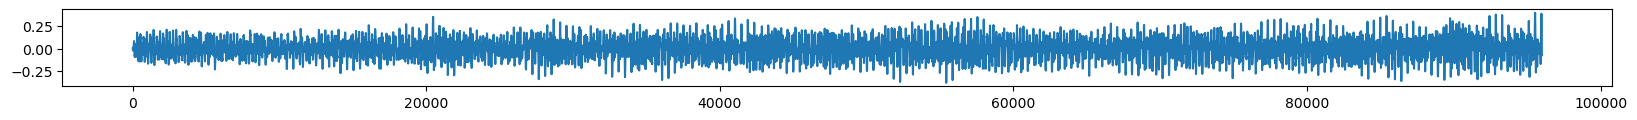

Finished epoch number 22 with a total of 10000 debug_seqs
 time: 2026-01-24 16:22:08.083773, epoch 23,  Loss: 0.2498
  Quantizer 0 Loss: 1.4345
  Quantizer 1 Loss: 2.7065
  Quantizer 2 Loss: 3.2842
  Quantizer 3 Loss: 3.5727
  Quantizer 4 Loss: 3.6899
  Quantizer 5 Loss: 3.7442
  Quantizer 6 Loss: 3.8608
  Quantizer 7 Loss: 3.8717
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


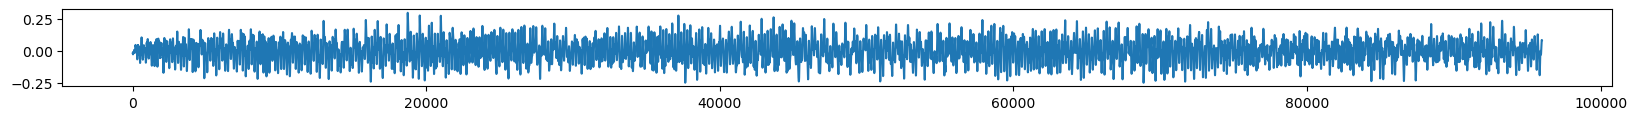

Finished epoch number 23 with a total of 10000 debug_seqs
 time: 2026-01-24 16:22:30.192667, epoch 24,  Loss: 0.2390
  Quantizer 0 Loss: 1.4150
  Quantizer 1 Loss: 2.6790
  Quantizer 2 Loss: 3.2659
  Quantizer 3 Loss: 3.5608
  Quantizer 4 Loss: 3.6765
  Quantizer 5 Loss: 3.7390
  Quantizer 6 Loss: 3.8542
  Quantizer 7 Loss: 3.8696
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


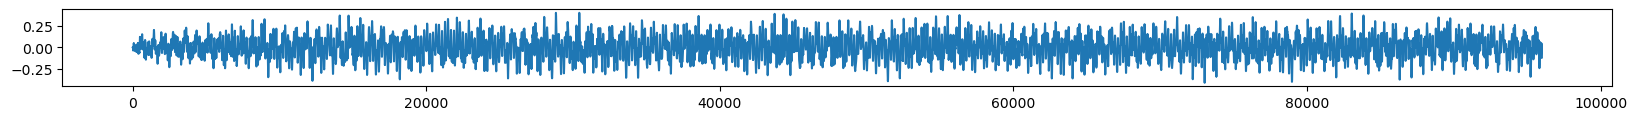

Finished epoch number 24 with a total of 10000 debug_seqs
 time: 2026-01-24 16:22:52.332571, epoch 25,  Loss: 0.2471
  Quantizer 0 Loss: 1.4109
  Quantizer 1 Loss: 2.6734
  Quantizer 2 Loss: 3.2573
  Quantizer 3 Loss: 3.5509
  Quantizer 4 Loss: 3.6701
  Quantizer 5 Loss: 3.7333
  Quantizer 6 Loss: 3.8497
  Quantizer 7 Loss: 3.8610
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


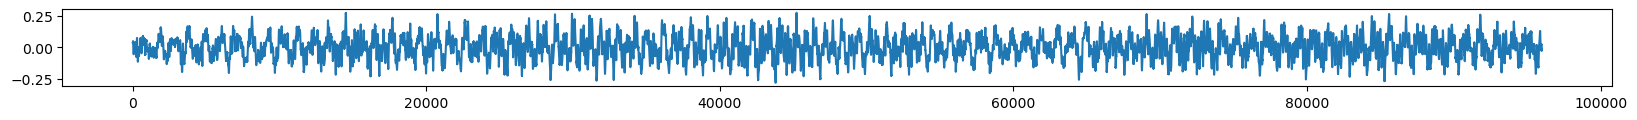

Saved checkpoint at epoch 25
Finished epoch number 25 with a total of 10000 debug_seqs
 time: 2026-01-24 16:23:19.196727, epoch 26,  Loss: 0.3038
  Quantizer 0 Loss: 1.5165
  Quantizer 1 Loss: 3.8512
  Quantizer 2 Loss: 4.6012
  Quantizer 3 Loss: 4.7986
  Quantizer 4 Loss: 4.6576
  Quantizer 5 Loss: 4.6771
  Quantizer 6 Loss: 4.6313
  Quantizer 7 Loss: 4.6035
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


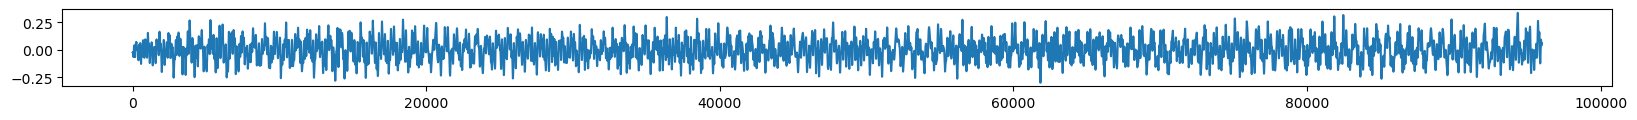

Finished epoch number 26 with a total of 10000 debug_seqs
 time: 2026-01-24 16:23:45.976213, epoch 27,  Loss: 0.2968
  Quantizer 0 Loss: 1.4523
  Quantizer 1 Loss: 3.5962
  Quantizer 2 Loss: 4.3166
  Quantizer 3 Loss: 4.5656
  Quantizer 4 Loss: 4.5205
  Quantizer 5 Loss: 4.5616
  Quantizer 6 Loss: 4.5771
  Quantizer 7 Loss: 4.5499
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


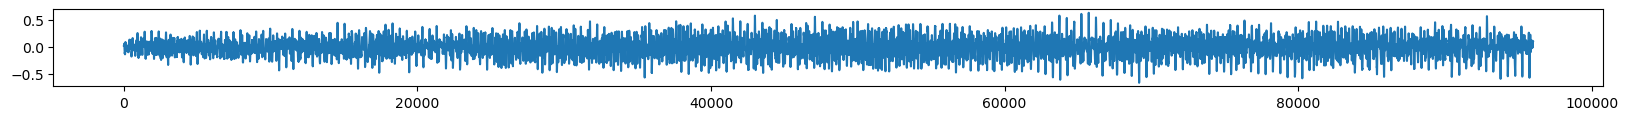

Finished epoch number 27 with a total of 10000 debug_seqs
 time: 2026-01-24 16:24:12.781372, epoch 28,  Loss: 0.2875
  Quantizer 0 Loss: 1.4228
  Quantizer 1 Loss: 3.4610
  Quantizer 2 Loss: 4.2144
  Quantizer 3 Loss: 4.4764
  Quantizer 4 Loss: 4.4908
  Quantizer 5 Loss: 4.5432
  Quantizer 6 Loss: 4.5699
  Quantizer 7 Loss: 4.5472
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


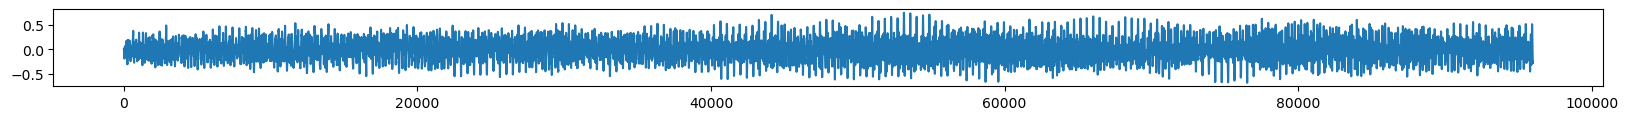

Finished epoch number 28 with a total of 10000 debug_seqs
 time: 2026-01-24 16:24:39.623235, epoch 29,  Loss: 0.2850
  Quantizer 0 Loss: 1.4024
  Quantizer 1 Loss: 3.3816
  Quantizer 2 Loss: 4.1912
  Quantizer 3 Loss: 4.4367
  Quantizer 4 Loss: 4.4443
  Quantizer 5 Loss: 4.5023
  Quantizer 6 Loss: 4.5303
  Quantizer 7 Loss: 4.5265
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


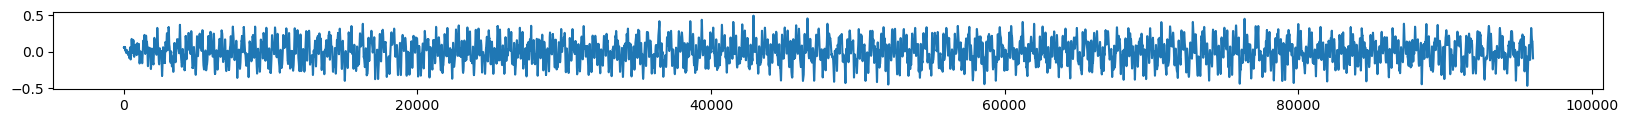

Finished epoch number 29 with a total of 10000 debug_seqs
 time: 2026-01-24 16:25:06.326268, epoch 30,  Loss: 0.2862
  Quantizer 0 Loss: 1.3914
  Quantizer 1 Loss: 3.3395
  Quantizer 2 Loss: 4.1372
  Quantizer 3 Loss: 4.3980
  Quantizer 4 Loss: 4.4244
  Quantizer 5 Loss: 4.4778
  Quantizer 6 Loss: 4.5232
  Quantizer 7 Loss: 4.5132
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


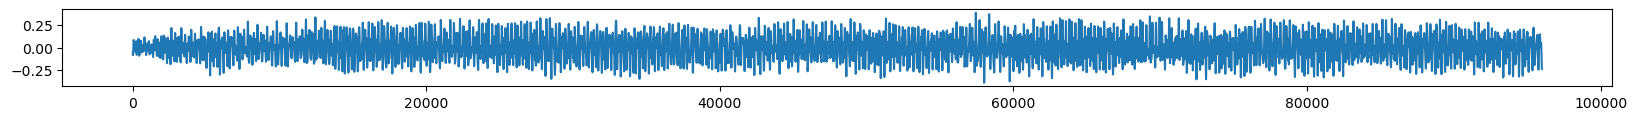

Finished epoch number 30 with a total of 10000 debug_seqs
 time: 2026-01-24 16:25:33.195504, epoch 31,  Loss: 0.2973
  Quantizer 0 Loss: 1.3732
  Quantizer 1 Loss: 3.3058
  Quantizer 2 Loss: 4.1001
  Quantizer 3 Loss: 4.3731
  Quantizer 4 Loss: 4.4013
  Quantizer 5 Loss: 4.4546
  Quantizer 6 Loss: 4.5050
  Quantizer 7 Loss: 4.4936
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


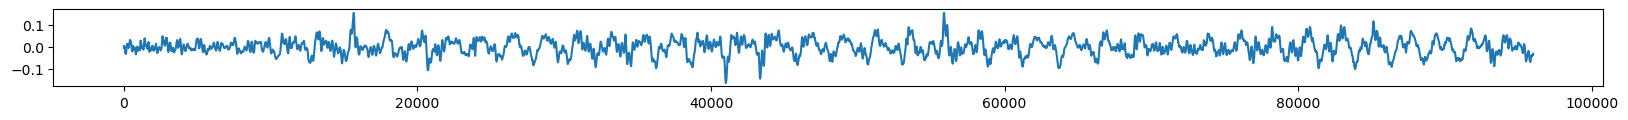

Finished epoch number 31 with a total of 10000 debug_seqs
 time: 2026-01-24 16:26:00.085742, epoch 32,  Loss: 0.2943
  Quantizer 0 Loss: 1.3772
  Quantizer 1 Loss: 3.3099
  Quantizer 2 Loss: 4.1116
  Quantizer 3 Loss: 4.3819
  Quantizer 4 Loss: 4.4090
  Quantizer 5 Loss: 4.4726
  Quantizer 6 Loss: 4.5277
  Quantizer 7 Loss: 4.5240
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


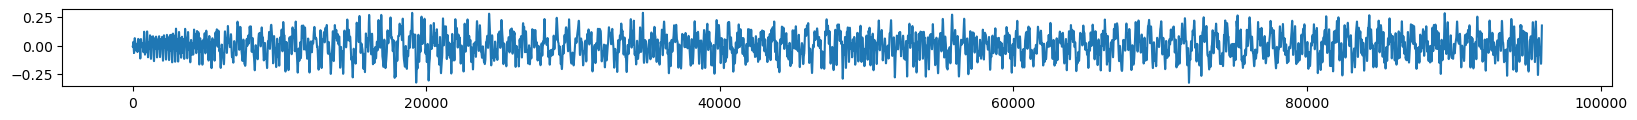

Finished epoch number 32 with a total of 10000 debug_seqs
 time: 2026-01-24 16:26:26.841328, epoch 33,  Loss: 0.2858
  Quantizer 0 Loss: 1.3629
  Quantizer 1 Loss: 3.2819
  Quantizer 2 Loss: 4.0920
  Quantizer 3 Loss: 4.3673
  Quantizer 4 Loss: 4.3935
  Quantizer 5 Loss: 4.4643
  Quantizer 6 Loss: 4.5154
  Quantizer 7 Loss: 4.5151
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


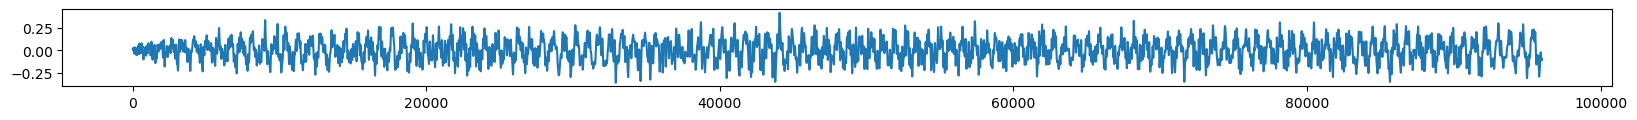

Finished epoch number 33 with a total of 10000 debug_seqs
 time: 2026-01-24 16:26:53.654488, epoch 34,  Loss: 0.2844
  Quantizer 0 Loss: 1.3515
  Quantizer 1 Loss: 3.2569
  Quantizer 2 Loss: 4.0658
  Quantizer 3 Loss: 4.3371
  Quantizer 4 Loss: 4.3668
  Quantizer 5 Loss: 4.4336
  Quantizer 6 Loss: 4.4916
  Quantizer 7 Loss: 4.4846
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


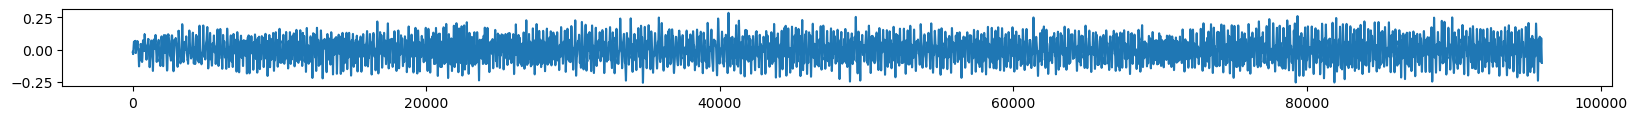

Finished epoch number 34 with a total of 10000 debug_seqs
 time: 2026-01-24 16:27:20.535448, epoch 35,  Loss: 0.2886
  Quantizer 0 Loss: 1.3406
  Quantizer 1 Loss: 3.2523
  Quantizer 2 Loss: 4.0625
  Quantizer 3 Loss: 4.3282
  Quantizer 4 Loss: 4.3643
  Quantizer 5 Loss: 4.4363
  Quantizer 6 Loss: 4.4915
  Quantizer 7 Loss: 4.4894
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


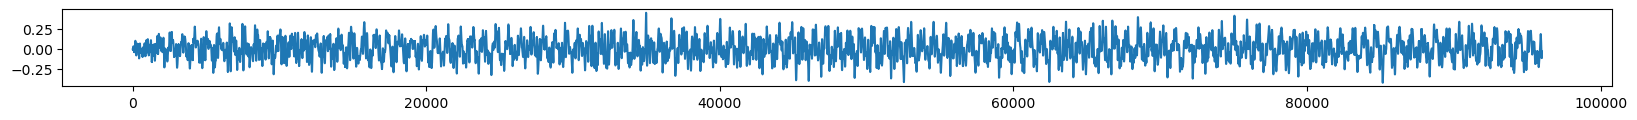

Finished epoch number 35 with a total of 10000 debug_seqs
 time: 2026-01-24 16:27:47.699583, epoch 36,  Loss: 0.2844
  Quantizer 0 Loss: 1.3379
  Quantizer 1 Loss: 3.2427
  Quantizer 2 Loss: 4.0646
  Quantizer 3 Loss: 4.3376
  Quantizer 4 Loss: 4.3769
  Quantizer 5 Loss: 4.4525
  Quantizer 6 Loss: 4.5100
  Quantizer 7 Loss: 4.5061
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


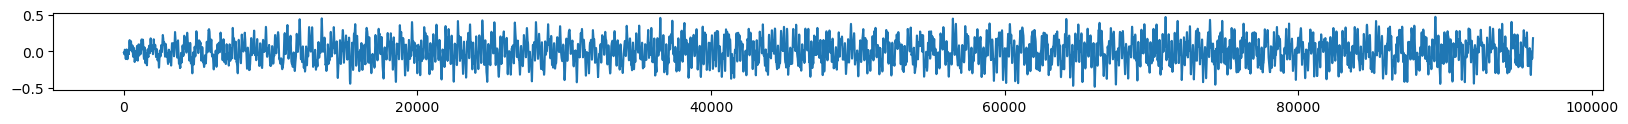

Finished epoch number 36 with a total of 10000 debug_seqs
 time: 2026-01-24 16:28:14.614033, epoch 37,  Loss: 0.2834
  Quantizer 0 Loss: 1.3376
  Quantizer 1 Loss: 3.2387
  Quantizer 2 Loss: 4.0608
  Quantizer 3 Loss: 4.3314
  Quantizer 4 Loss: 4.3744
  Quantizer 5 Loss: 4.4459
  Quantizer 6 Loss: 4.5038
  Quantizer 7 Loss: 4.5052
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


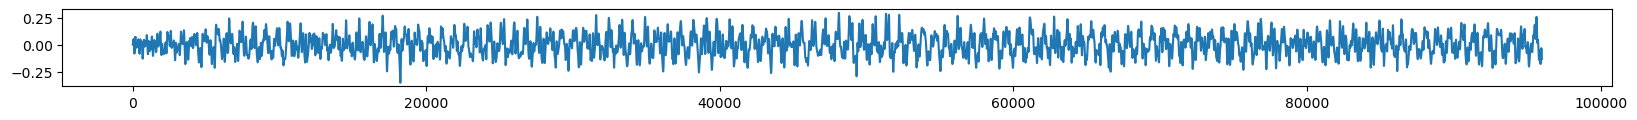

Finished epoch number 37 with a total of 10000 debug_seqs
 time: 2026-01-24 16:28:41.737558, epoch 38,  Loss: 0.2899
  Quantizer 0 Loss: 1.3311
  Quantizer 1 Loss: 3.2194
  Quantizer 2 Loss: 4.0436
  Quantizer 3 Loss: 4.3111
  Quantizer 4 Loss: 4.3600
  Quantizer 5 Loss: 4.4316
  Quantizer 6 Loss: 4.4910
  Quantizer 7 Loss: 4.4916
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


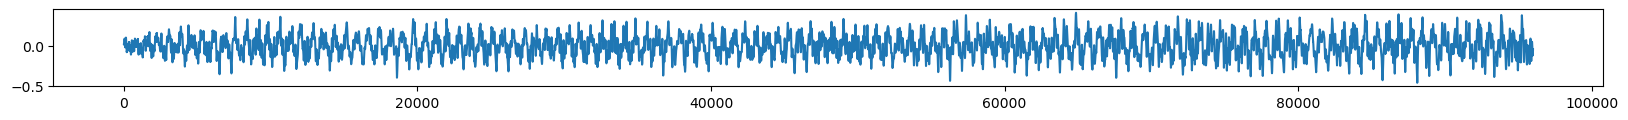

Finished epoch number 38 with a total of 10000 debug_seqs
 time: 2026-01-24 16:29:08.580871, epoch 39,  Loss: 0.2786
  Quantizer 0 Loss: 1.3273
  Quantizer 1 Loss: 3.2248
  Quantizer 2 Loss: 4.0375
  Quantizer 3 Loss: 4.3173
  Quantizer 4 Loss: 4.3662
  Quantizer 5 Loss: 4.4388
  Quantizer 6 Loss: 4.4987
  Quantizer 7 Loss: 4.4980
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


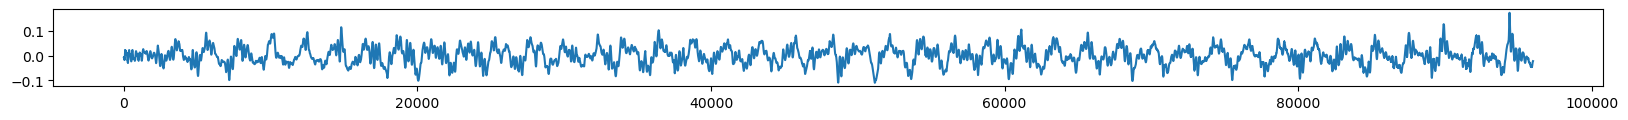

Finished epoch number 39 with a total of 10000 debug_seqs
 time: 2026-01-24 16:29:35.489742, epoch 40,  Loss: 0.2824
  Quantizer 0 Loss: 1.3205
  Quantizer 1 Loss: 3.2080
  Quantizer 2 Loss: 4.0311
  Quantizer 3 Loss: 4.3152
  Quantizer 4 Loss: 4.3620
  Quantizer 5 Loss: 4.4283
  Quantizer 6 Loss: 4.4914
  Quantizer 7 Loss: 4.4929
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


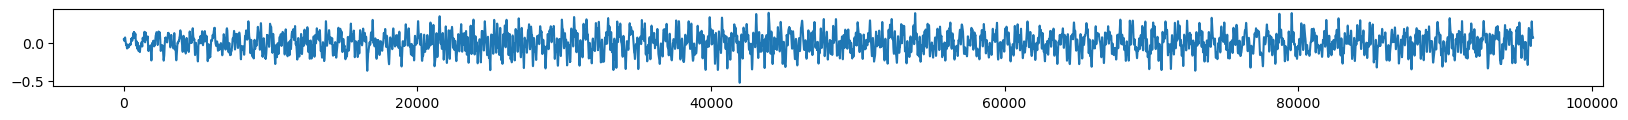

Finished epoch number 40 with a total of 10000 debug_seqs
 time: 2026-01-24 16:30:02.636461, epoch 41,  Loss: 0.2842
  Quantizer 0 Loss: 1.3150
  Quantizer 1 Loss: 3.1968
  Quantizer 2 Loss: 4.0228
  Quantizer 3 Loss: 4.3068
  Quantizer 4 Loss: 4.3496
  Quantizer 5 Loss: 4.4195
  Quantizer 6 Loss: 4.4900
  Quantizer 7 Loss: 4.4901
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


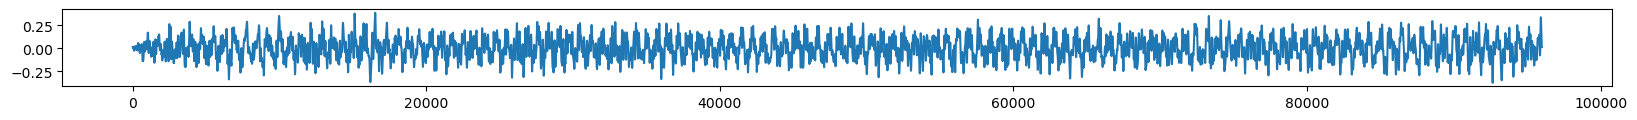

Finished epoch number 41 with a total of 10000 debug_seqs
 time: 2026-01-24 16:30:30.134260, epoch 42,  Loss: 0.2816
  Quantizer 0 Loss: 1.3084
  Quantizer 1 Loss: 3.1903
  Quantizer 2 Loss: 4.0104
  Quantizer 3 Loss: 4.2972
  Quantizer 4 Loss: 4.3481
  Quantizer 5 Loss: 4.4128
  Quantizer 6 Loss: 4.4738
  Quantizer 7 Loss: 4.4799
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


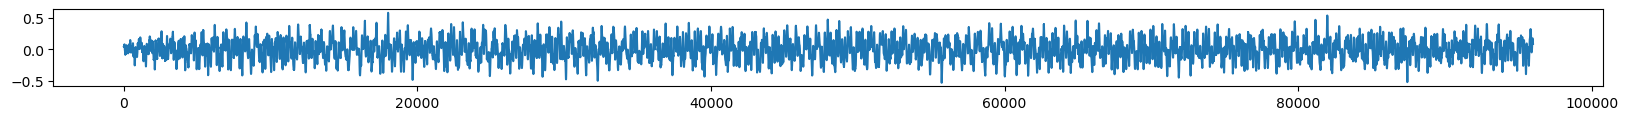

Finished epoch number 42 with a total of 10000 debug_seqs
 time: 2026-01-24 16:30:57.246457, epoch 43,  Loss: 0.2983
  Quantizer 0 Loss: 1.3096
  Quantizer 1 Loss: 3.1800
  Quantizer 2 Loss: 4.0015
  Quantizer 3 Loss: 4.2914
  Quantizer 4 Loss: 4.3357
  Quantizer 5 Loss: 4.4083
  Quantizer 6 Loss: 4.4683
  Quantizer 7 Loss: 4.4728
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


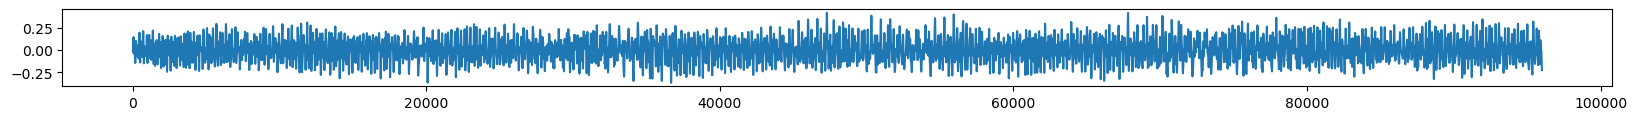

Finished epoch number 43 with a total of 10000 debug_seqs
 time: 2026-01-24 16:31:24.546177, epoch 44,  Loss: 0.2789
  Quantizer 0 Loss: 1.3070
  Quantizer 1 Loss: 3.1883
  Quantizer 2 Loss: 4.0121
  Quantizer 3 Loss: 4.2964
  Quantizer 4 Loss: 4.3447
  Quantizer 5 Loss: 4.4236
  Quantizer 6 Loss: 4.4835
  Quantizer 7 Loss: 4.4926
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


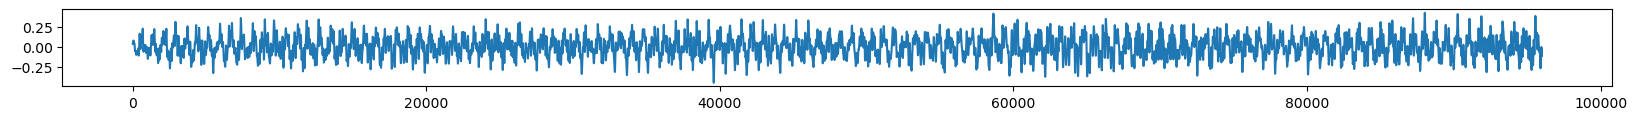

Finished epoch number 44 with a total of 10000 debug_seqs
 time: 2026-01-24 16:31:52.138422, epoch 45,  Loss: 0.2834
  Quantizer 0 Loss: 1.3031
  Quantizer 1 Loss: 3.1747
  Quantizer 2 Loss: 4.0114
  Quantizer 3 Loss: 4.2918
  Quantizer 4 Loss: 4.3442
  Quantizer 5 Loss: 4.4152
  Quantizer 6 Loss: 4.4797
  Quantizer 7 Loss: 4.4916
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


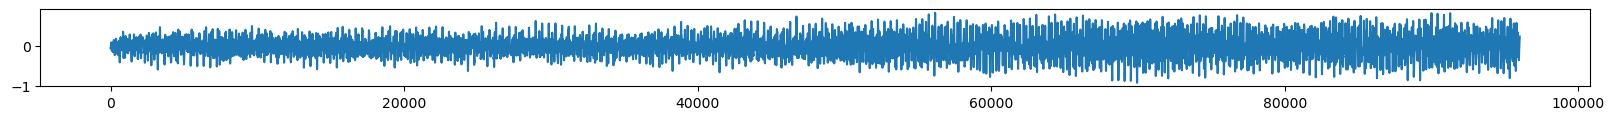

Finished epoch number 45 with a total of 10000 debug_seqs
 time: 2026-01-24 16:32:19.061386, epoch 46,  Loss: 0.2715
  Quantizer 0 Loss: 1.3017
  Quantizer 1 Loss: 3.1709
  Quantizer 2 Loss: 3.9950
  Quantizer 3 Loss: 4.2765
  Quantizer 4 Loss: 4.3252
  Quantizer 5 Loss: 4.4024
  Quantizer 6 Loss: 4.4665
  Quantizer 7 Loss: 4.4699
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


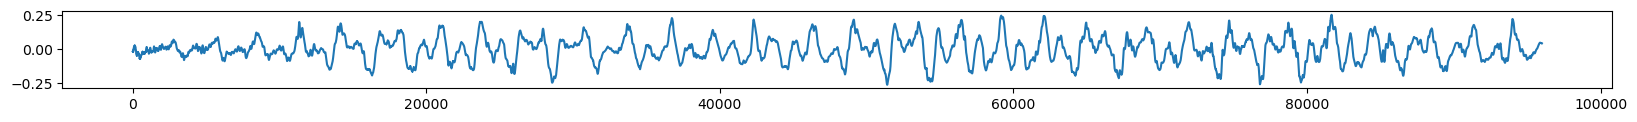

Finished epoch number 46 with a total of 10000 debug_seqs
 time: 2026-01-24 16:32:45.911535, epoch 47,  Loss: 0.2868
  Quantizer 0 Loss: 1.2950
  Quantizer 1 Loss: 3.1568
  Quantizer 2 Loss: 3.9835
  Quantizer 3 Loss: 4.2665
  Quantizer 4 Loss: 4.3186
  Quantizer 5 Loss: 4.3929
  Quantizer 6 Loss: 4.4605
  Quantizer 7 Loss: 4.4651
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


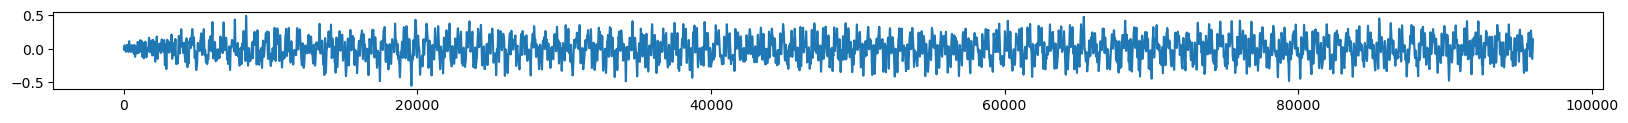

Finished epoch number 47 with a total of 10000 debug_seqs
 time: 2026-01-24 16:33:13.229306, epoch 48,  Loss: 0.2744
  Quantizer 0 Loss: 1.2885
  Quantizer 1 Loss: 3.1577
  Quantizer 2 Loss: 3.9909
  Quantizer 3 Loss: 4.2823
  Quantizer 4 Loss: 4.3315
  Quantizer 5 Loss: 4.4081
  Quantizer 6 Loss: 4.4735
  Quantizer 7 Loss: 4.4796
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


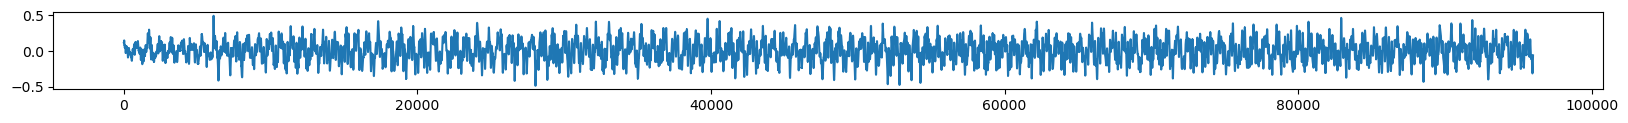

Finished epoch number 48 with a total of 10000 debug_seqs
 time: 2026-01-24 16:33:40.328211, epoch 49,  Loss: 0.2726
  Quantizer 0 Loss: 1.2863
  Quantizer 1 Loss: 3.1551
  Quantizer 2 Loss: 3.9841
  Quantizer 3 Loss: 4.2755
  Quantizer 4 Loss: 4.3240
  Quantizer 5 Loss: 4.4040
  Quantizer 6 Loss: 4.4685
  Quantizer 7 Loss: 4.4740
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


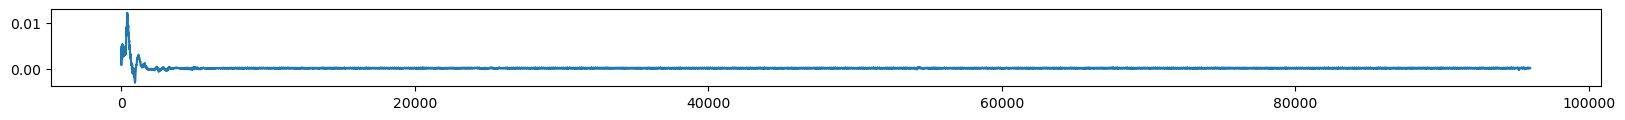

Finished epoch number 49 with a total of 10000 debug_seqs
 time: 2026-01-24 16:34:07.464429, epoch 50,  Loss: 0.2742
  Quantizer 0 Loss: 1.2801
  Quantizer 1 Loss: 3.1381
  Quantizer 2 Loss: 3.9732
  Quantizer 3 Loss: 4.2571
  Quantizer 4 Loss: 4.3173
  Quantizer 5 Loss: 4.3915
  Quantizer 6 Loss: 4.4568
  Quantizer 7 Loss: 4.4668
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


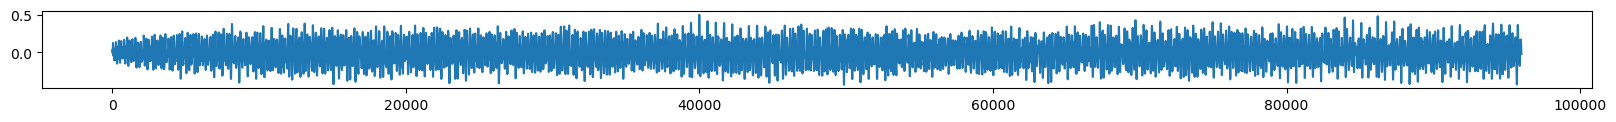

Saved checkpoint at epoch 50
Finished epoch number 50 with a total of 10000 debug_seqs
 time: 2026-01-24 16:34:29.956078, epoch 51,  Loss: 0.2378
  Quantizer 0 Loss: 1.2546
  Quantizer 1 Loss: 2.5678
  Quantizer 2 Loss: 3.2869
  Quantizer 3 Loss: 3.6438
  Quantizer 4 Loss: 3.7755
  Quantizer 5 Loss: 3.8574
  Quantizer 6 Loss: 3.9690
  Quantizer 7 Loss: 3.9858
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


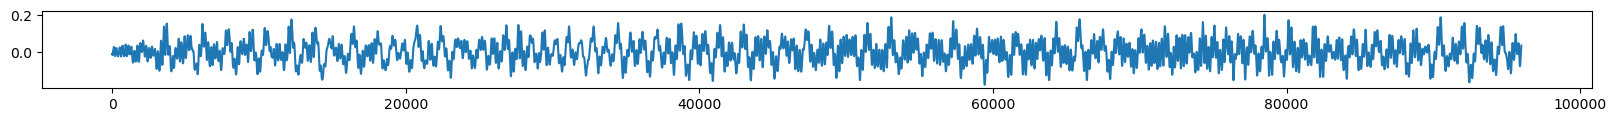

Finished epoch number 51 with a total of 10000 debug_seqs
 time: 2026-01-24 16:34:52.754928, epoch 52,  Loss: 0.2341
  Quantizer 0 Loss: 1.2738
  Quantizer 1 Loss: 2.5324
  Quantizer 2 Loss: 3.1850
  Quantizer 3 Loss: 3.5252
  Quantizer 4 Loss: 3.6689
  Quantizer 5 Loss: 3.7523
  Quantizer 6 Loss: 3.8775
  Quantizer 7 Loss: 3.9002
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


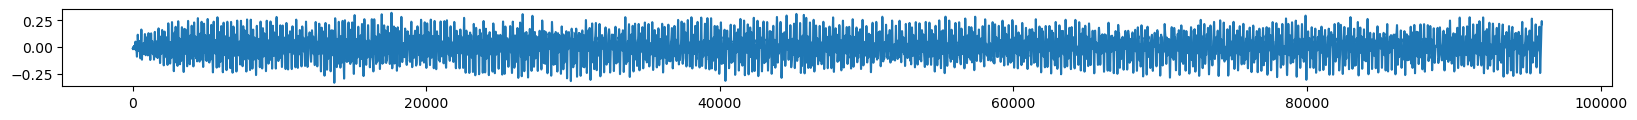

Finished epoch number 52 with a total of 10000 debug_seqs
 time: 2026-01-24 16:35:15.659383, epoch 53,  Loss: 0.2354
  Quantizer 0 Loss: 1.2510
  Quantizer 1 Loss: 2.4900
  Quantizer 2 Loss: 3.1248
  Quantizer 3 Loss: 3.4684
  Quantizer 4 Loss: 3.6173
  Quantizer 5 Loss: 3.7050
  Quantizer 6 Loss: 3.8315
  Quantizer 7 Loss: 3.8589
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


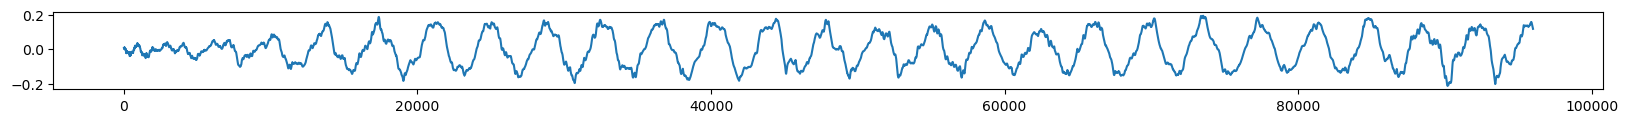

Finished epoch number 53 with a total of 10000 debug_seqs
 time: 2026-01-24 16:35:37.944223, epoch 54,  Loss: 0.2319
  Quantizer 0 Loss: 1.2595
  Quantizer 1 Loss: 2.4778
  Quantizer 2 Loss: 3.1037
  Quantizer 3 Loss: 3.4443
  Quantizer 4 Loss: 3.5960
  Quantizer 5 Loss: 3.6772
  Quantizer 6 Loss: 3.8081
  Quantizer 7 Loss: 3.8399
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


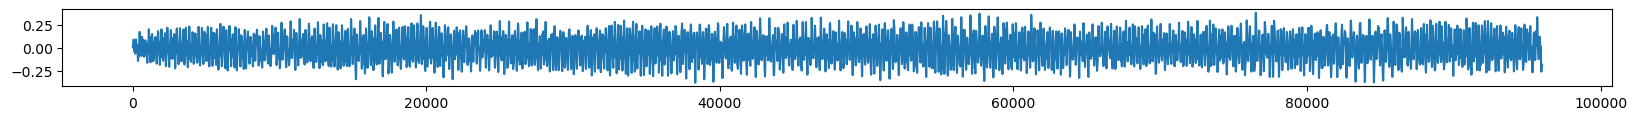

Finished epoch number 54 with a total of 10000 debug_seqs
 time: 2026-01-24 16:36:00.428073, epoch 55,  Loss: 0.2352
  Quantizer 0 Loss: 1.2663
  Quantizer 1 Loss: 2.4769
  Quantizer 2 Loss: 3.0996
  Quantizer 3 Loss: 3.4498
  Quantizer 4 Loss: 3.6024
  Quantizer 5 Loss: 3.6902
  Quantizer 6 Loss: 3.8211
  Quantizer 7 Loss: 3.8493
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


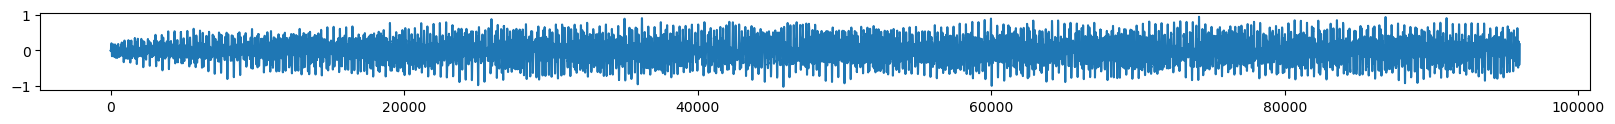

Finished epoch number 55 with a total of 10000 debug_seqs
 time: 2026-01-24 16:36:23.185762, epoch 56,  Loss: 0.2298
  Quantizer 0 Loss: 1.2558
  Quantizer 1 Loss: 2.4602
  Quantizer 2 Loss: 3.0733
  Quantizer 3 Loss: 3.4228
  Quantizer 4 Loss: 3.5736
  Quantizer 5 Loss: 3.6568
  Quantizer 6 Loss: 3.7896
  Quantizer 7 Loss: 3.8171
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


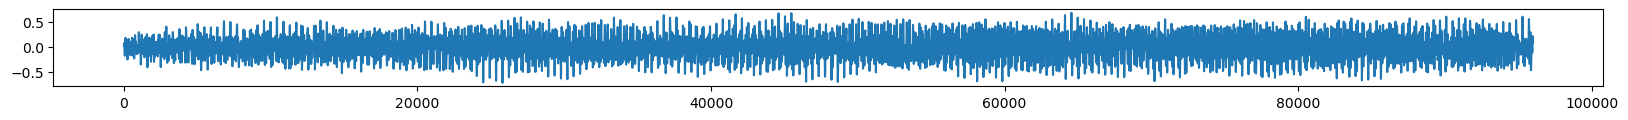

Finished epoch number 56 with a total of 10000 debug_seqs
 time: 2026-01-24 16:36:45.807701, epoch 57,  Loss: 0.2239
  Quantizer 0 Loss: 1.2453
  Quantizer 1 Loss: 2.4397
  Quantizer 2 Loss: 3.0601
  Quantizer 3 Loss: 3.3981
  Quantizer 4 Loss: 3.5573
  Quantizer 5 Loss: 3.6460
  Quantizer 6 Loss: 3.7817
  Quantizer 7 Loss: 3.8087
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


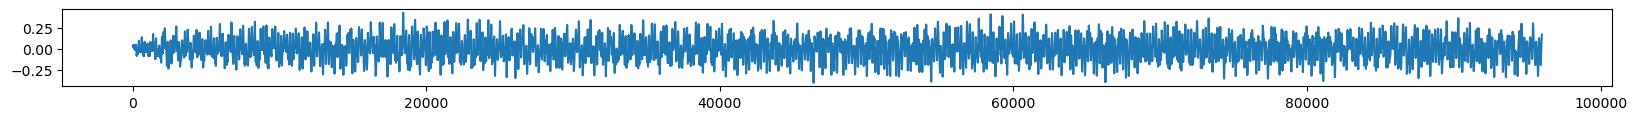

Finished epoch number 57 with a total of 10000 debug_seqs
 time: 2026-01-24 16:37:08.074234, epoch 58,  Loss: 0.2260
  Quantizer 0 Loss: 1.2485
  Quantizer 1 Loss: 2.4287
  Quantizer 2 Loss: 3.0392
  Quantizer 3 Loss: 3.3814
  Quantizer 4 Loss: 3.5390
  Quantizer 5 Loss: 3.6226
  Quantizer 6 Loss: 3.7590
  Quantizer 7 Loss: 3.7907
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


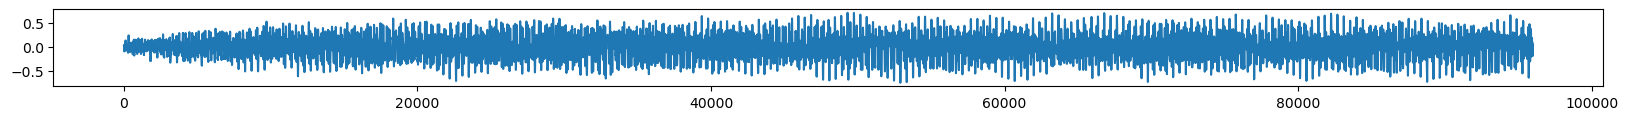

Finished epoch number 58 with a total of 10000 debug_seqs
 time: 2026-01-24 16:37:31.047234, epoch 59,  Loss: 0.2218
  Quantizer 0 Loss: 1.2376
  Quantizer 1 Loss: 2.4181
  Quantizer 2 Loss: 3.0306
  Quantizer 3 Loss: 3.3790
  Quantizer 4 Loss: 3.5417
  Quantizer 5 Loss: 3.6315
  Quantizer 6 Loss: 3.7694
  Quantizer 7 Loss: 3.7911
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


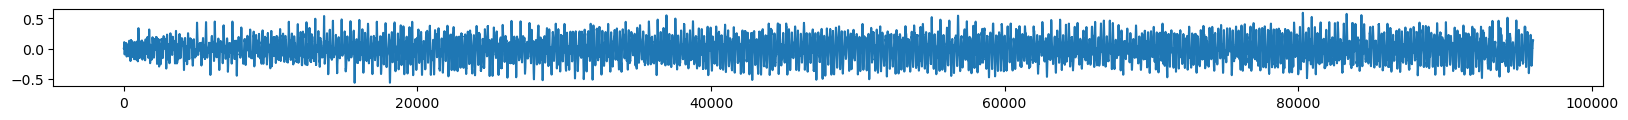

Finished epoch number 59 with a total of 10000 debug_seqs
 time: 2026-01-24 16:37:55.020626, epoch 60,  Loss: 0.2260
  Quantizer 0 Loss: 1.2494
  Quantizer 1 Loss: 2.4303
  Quantizer 2 Loss: 3.0371
  Quantizer 3 Loss: 3.3838
  Quantizer 4 Loss: 3.5479
  Quantizer 5 Loss: 3.6359
  Quantizer 6 Loss: 3.7715
  Quantizer 7 Loss: 3.8035
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


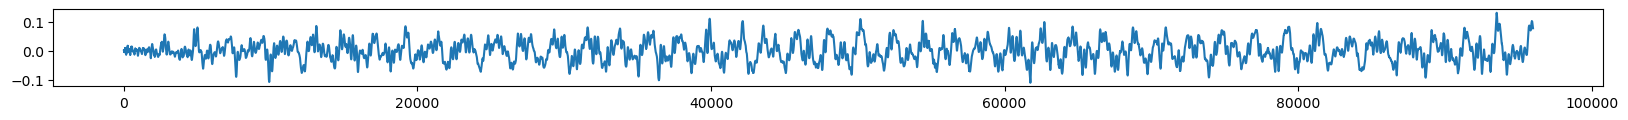

Finished epoch number 60 with a total of 10000 debug_seqs
 time: 2026-01-24 16:38:17.861602, epoch 61,  Loss: 0.2307
  Quantizer 0 Loss: 1.2412
  Quantizer 1 Loss: 2.4108
  Quantizer 2 Loss: 3.0211
  Quantizer 3 Loss: 3.3717
  Quantizer 4 Loss: 3.5342
  Quantizer 5 Loss: 3.6253
  Quantizer 6 Loss: 3.7683
  Quantizer 7 Loss: 3.7899
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


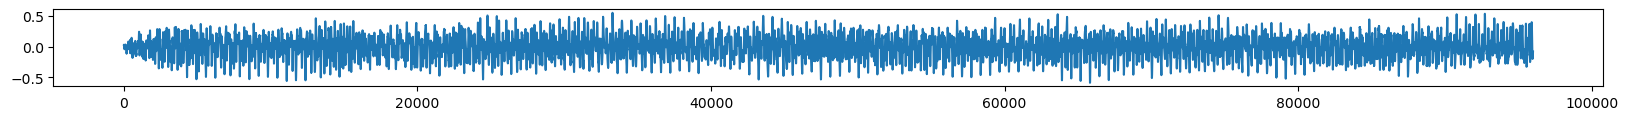

Finished epoch number 61 with a total of 10000 debug_seqs
 time: 2026-01-24 16:38:40.882515, epoch 62,  Loss: 0.2232
  Quantizer 0 Loss: 1.2380
  Quantizer 1 Loss: 2.4070
  Quantizer 2 Loss: 3.0087
  Quantizer 3 Loss: 3.3643
  Quantizer 4 Loss: 3.5256
  Quantizer 5 Loss: 3.6211
  Quantizer 6 Loss: 3.7578
  Quantizer 7 Loss: 3.7869
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


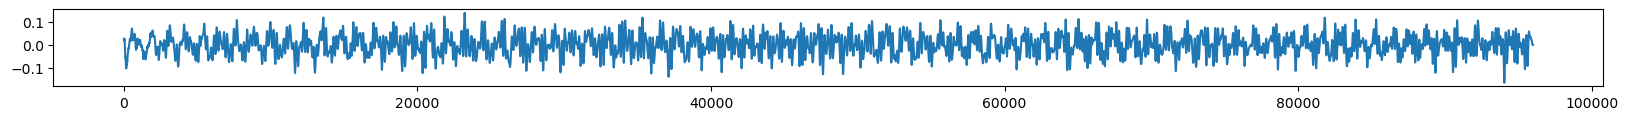

Finished epoch number 62 with a total of 10000 debug_seqs
 time: 2026-01-24 16:39:03.601876, epoch 63,  Loss: 0.2202
  Quantizer 0 Loss: 1.2421
  Quantizer 1 Loss: 2.4140
  Quantizer 2 Loss: 3.0144
  Quantizer 3 Loss: 3.3615
  Quantizer 4 Loss: 3.5285
  Quantizer 5 Loss: 3.6185
  Quantizer 6 Loss: 3.7532
  Quantizer 7 Loss: 3.7825
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


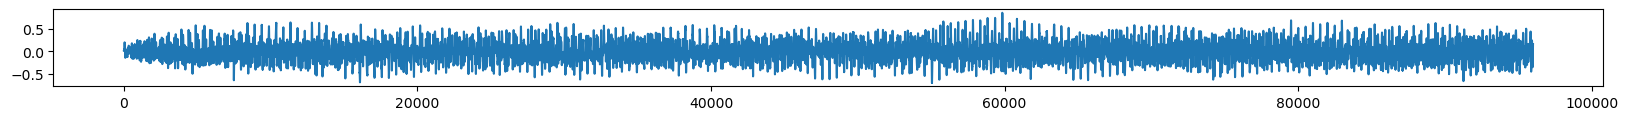

Finished epoch number 63 with a total of 10000 debug_seqs
 time: 2026-01-24 16:39:26.243529, epoch 64,  Loss: 0.2323
  Quantizer 0 Loss: 1.2254
  Quantizer 1 Loss: 2.3847
  Quantizer 2 Loss: 2.9897
  Quantizer 3 Loss: 3.3423
  Quantizer 4 Loss: 3.5101
  Quantizer 5 Loss: 3.6001
  Quantizer 6 Loss: 3.7381
  Quantizer 7 Loss: 3.7668
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


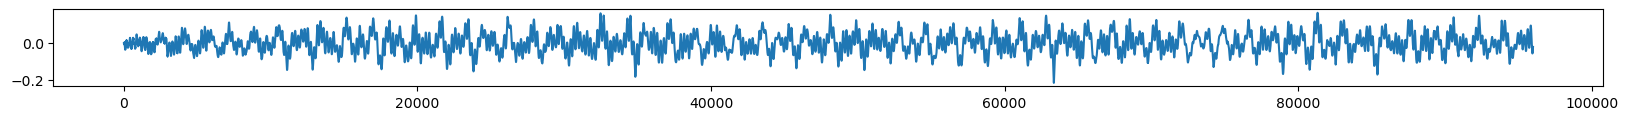

Finished epoch number 64 with a total of 10000 debug_seqs
 time: 2026-01-24 16:39:49.524598, epoch 65,  Loss: 0.2298
  Quantizer 0 Loss: 1.2350
  Quantizer 1 Loss: 2.3970
  Quantizer 2 Loss: 2.9970
  Quantizer 3 Loss: 3.3530
  Quantizer 4 Loss: 3.5191
  Quantizer 5 Loss: 3.6142
  Quantizer 6 Loss: 3.7499
  Quantizer 7 Loss: 3.7826
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


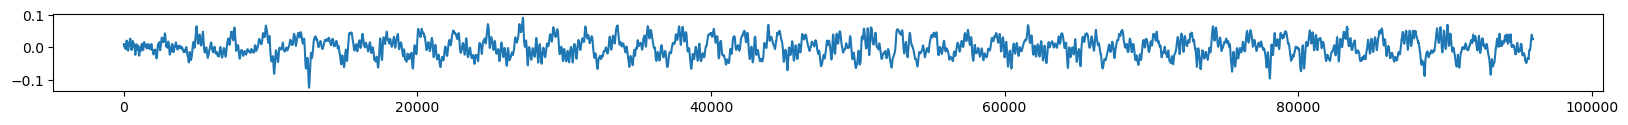

Finished epoch number 65 with a total of 10000 debug_seqs
 time: 2026-01-24 16:40:12.072286, epoch 66,  Loss: 0.2275
  Quantizer 0 Loss: 1.2280
  Quantizer 1 Loss: 2.3922
  Quantizer 2 Loss: 2.9908
  Quantizer 3 Loss: 3.3445
  Quantizer 4 Loss: 3.5138
  Quantizer 5 Loss: 3.6056
  Quantizer 6 Loss: 3.7492
  Quantizer 7 Loss: 3.7730
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


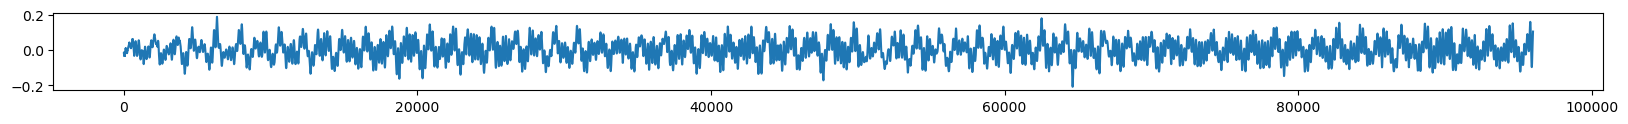

Finished epoch number 66 with a total of 10000 debug_seqs
 time: 2026-01-24 16:40:34.406526, epoch 67,  Loss: 0.2218
  Quantizer 0 Loss: 1.2265
  Quantizer 1 Loss: 2.3792
  Quantizer 2 Loss: 2.9807
  Quantizer 3 Loss: 3.3332
  Quantizer 4 Loss: 3.5062
  Quantizer 5 Loss: 3.6034
  Quantizer 6 Loss: 3.7392
  Quantizer 7 Loss: 3.7713
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


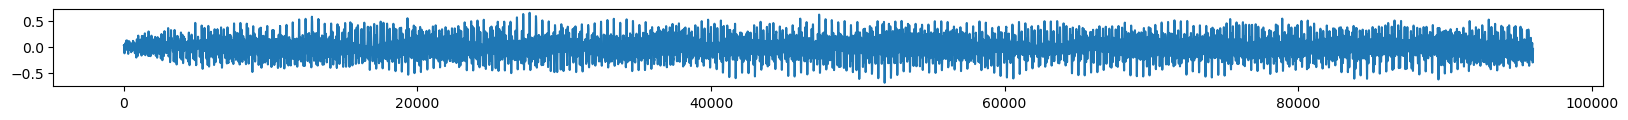

Finished epoch number 67 with a total of 10000 debug_seqs
 time: 2026-01-24 16:40:57.292355, epoch 68,  Loss: 0.2270
  Quantizer 0 Loss: 1.2300
  Quantizer 1 Loss: 2.3858
  Quantizer 2 Loss: 2.9866
  Quantizer 3 Loss: 3.3332
  Quantizer 4 Loss: 3.5118
  Quantizer 5 Loss: 3.6053
  Quantizer 6 Loss: 3.7404
  Quantizer 7 Loss: 3.7729
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


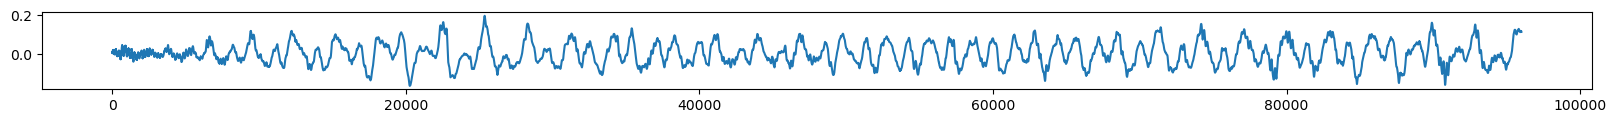

Finished epoch number 68 with a total of 10000 debug_seqs
 time: 2026-01-24 16:41:20.008434, epoch 69,  Loss: 0.2269
  Quantizer 0 Loss: 1.2157
  Quantizer 1 Loss: 2.3701
  Quantizer 2 Loss: 2.9607
  Quantizer 3 Loss: 3.3161
  Quantizer 4 Loss: 3.4947
  Quantizer 5 Loss: 3.5905
  Quantizer 6 Loss: 3.7341
  Quantizer 7 Loss: 3.7627
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


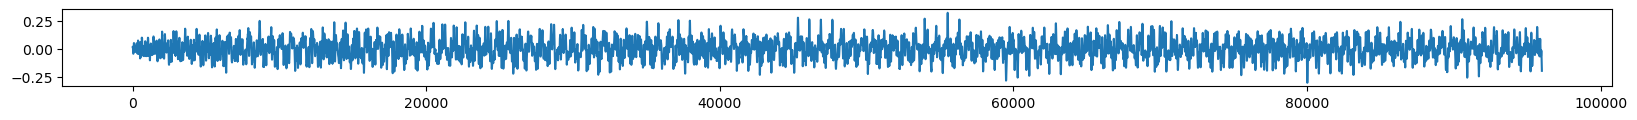

Finished epoch number 69 with a total of 10000 debug_seqs
 time: 2026-01-24 16:41:42.209674, epoch 70,  Loss: 0.2297
  Quantizer 0 Loss: 1.2162
  Quantizer 1 Loss: 2.3642
  Quantizer 2 Loss: 2.9548
  Quantizer 3 Loss: 3.3133
  Quantizer 4 Loss: 3.4902
  Quantizer 5 Loss: 3.5865
  Quantizer 6 Loss: 3.7224
  Quantizer 7 Loss: 3.7585
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


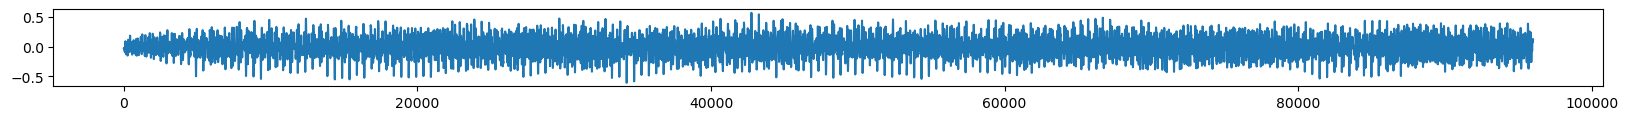

Finished epoch number 70 with a total of 10000 debug_seqs
 time: 2026-01-24 16:42:04.439555, epoch 71,  Loss: 0.2227
  Quantizer 0 Loss: 1.2155
  Quantizer 1 Loss: 2.3578
  Quantizer 2 Loss: 2.9540
  Quantizer 3 Loss: 3.3119
  Quantizer 4 Loss: 3.4845
  Quantizer 5 Loss: 3.5824
  Quantizer 6 Loss: 3.7261
  Quantizer 7 Loss: 3.7545
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


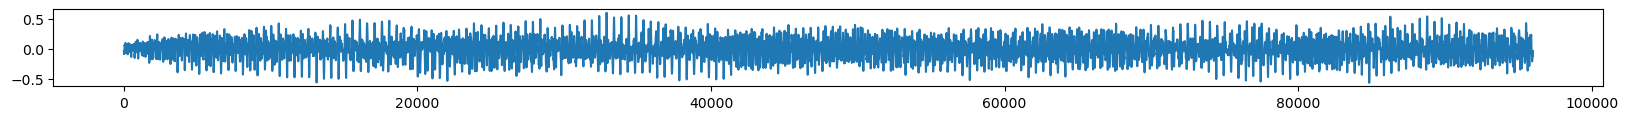

Finished epoch number 71 with a total of 10000 debug_seqs
 time: 2026-01-24 16:42:26.874178, epoch 72,  Loss: 0.2205
  Quantizer 0 Loss: 1.2150
  Quantizer 1 Loss: 2.3607
  Quantizer 2 Loss: 2.9495
  Quantizer 3 Loss: 3.3109
  Quantizer 4 Loss: 3.4869
  Quantizer 5 Loss: 3.5900
  Quantizer 6 Loss: 3.7264
  Quantizer 7 Loss: 3.7593
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


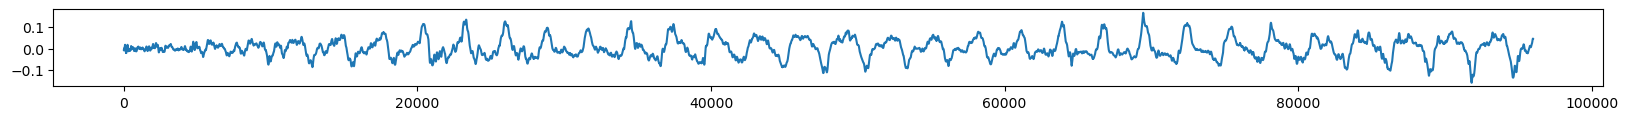

Finished epoch number 72 with a total of 10000 debug_seqs
 time: 2026-01-24 16:42:49.196310, epoch 73,  Loss: 0.2229
  Quantizer 0 Loss: 1.2098
  Quantizer 1 Loss: 2.3516
  Quantizer 2 Loss: 2.9383
  Quantizer 3 Loss: 3.2999
  Quantizer 4 Loss: 3.4779
  Quantizer 5 Loss: 3.5755
  Quantizer 6 Loss: 3.7135
  Quantizer 7 Loss: 3.7454
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


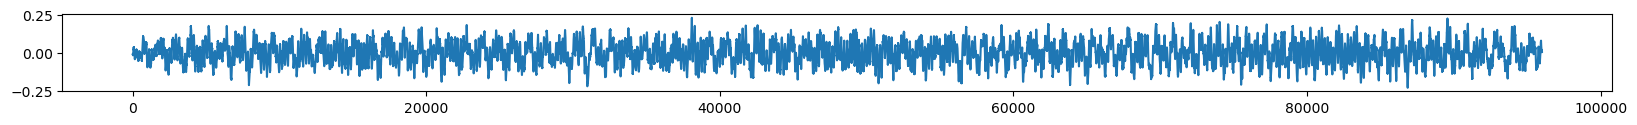

Finished epoch number 73 with a total of 10000 debug_seqs
 time: 2026-01-24 16:43:12.002307, epoch 74,  Loss: 0.2225
  Quantizer 0 Loss: 1.2101
  Quantizer 1 Loss: 2.3491
  Quantizer 2 Loss: 2.9449
  Quantizer 3 Loss: 3.3038
  Quantizer 4 Loss: 3.4817
  Quantizer 5 Loss: 3.5870
  Quantizer 6 Loss: 3.7246
  Quantizer 7 Loss: 3.7599
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


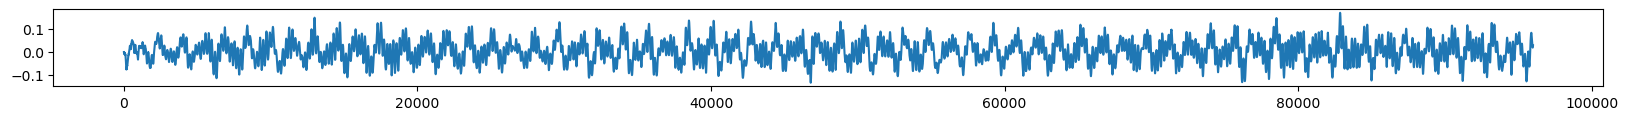

Finished epoch number 74 with a total of 10000 debug_seqs
 time: 2026-01-24 16:43:34.612255, epoch 75,  Loss: 0.2178
  Quantizer 0 Loss: 1.1988
  Quantizer 1 Loss: 2.3315
  Quantizer 2 Loss: 2.9220
  Quantizer 3 Loss: 3.2822
  Quantizer 4 Loss: 3.4580
  Quantizer 5 Loss: 3.5570
  Quantizer 6 Loss: 3.6979
  Quantizer 7 Loss: 3.7348
Latents embedded in 91 of the GRU input size of 128
Conditioning parameters embedded in 37 of the GRU input size of 128
DEVICE going in: model tensors cuda:0, enc_model cpu, c cuda:0
About toInitialize generator with c.shape = torch.Size([2])
params_seq.shape = torch.Size([10, 2])
plot the audio which has shape (96000,)


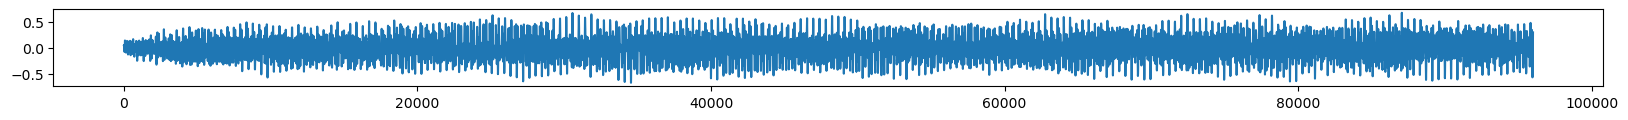

Saved checkpoint at epoch 75
Training time taken: 0:29:58
Saved checkpoint at epoch 75


'/home/lonce/working/RNeNcodec/dev_notebooks/output/20260124_161336_engineC_SOFTtrial_TFCYCLE_TAU.35_topnsoft_postmerge/checkpoints/last_checkpoint.pt'

In [16]:
# Train!
#*************************************
enc_model.to(device)
list_of_losses = []

print('{:%Y-%m-%d %H:%M:%S} Starting training...'.format(datetime.now()))
start_time = time.monotonic()
#-------------------------------------------------------------------------------
for epoch in range(start_epoch, start_epoch+params['num_epochs']):
    train(rnn,enc_model,epoch)
#-------------------------------------------------------------------------------
writer.close()
elapsed_time = time.monotonic() - start_time
print('Training time taken:',time_taken(elapsed_time))

#Just make sure the final model gets saved
checkpoint_data = {
    'epoch': epoch+1,
    'model_state_dict': rnn.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}
# Save numbered checkpoint
numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
torch.save(checkpoint_data, numbered_path)
print(f"Saved checkpoint at epoch {epoch+1}")
# Copy to "last" (much faster than saving twice)
last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
shutil.copy2(numbered_path, last_path)


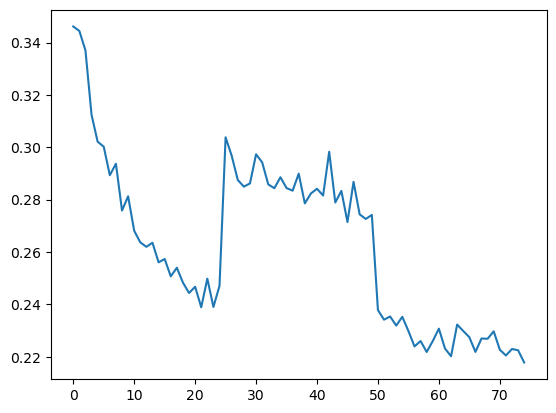

In [17]:
# Plot the loss over time
#*************************************
plt.figure()
plt.plot(list_of_losses)
plt.show()  # This will actually display the plot

In [18]:
list_of_losses

[0.346160888671875,
 0.3444490814208984,
 0.3370234680175781,
 0.3124018478393555,
 0.3021491813659668,
 0.3002327346801758,
 0.28933761596679686,
 0.2937156867980957,
 0.2758523178100586,
 0.2812885475158691,
 0.26811187744140624,
 0.26368715286254885,
 0.261982421875,
 0.2635467529296875,
 0.2560614013671875,
 0.2573337173461914,
 0.2507197952270508,
 0.2539948844909668,
 0.24830699920654298,
 0.2443569755554199,
 0.24673763275146485,
 0.23889316558837892,
 0.24983558654785157,
 0.23900995254516602,
 0.24707921981811523,
 0.3038347816467285,
 0.2967722129821777,
 0.2875112724304199,
 0.28497968673706053,
 0.28620849609375,
 0.29733551025390625,
 0.2942644500732422,
 0.2858449935913086,
 0.28437477111816406,
 0.28856428146362306,
 0.28444576263427734,
 0.28343212127685546,
 0.2899258422851563,
 0.27858346939086914,
 0.2823642921447754,
 0.28417411804199216,
 0.2815863037109375,
 0.29826820373535157,
 0.2789199447631836,
 0.2833631134033203,
 0.2714585304260254,
 0.2868033409118652,
 0